# Исследование поведения покупателей интернет-магазина с целью увеличения продаж и лояльности клиентов путем сегментированного маркетинга

**Описание**\
Я работаю джуниор-специалистом в интернет-магазине товаров для дома «Пока все ещё тут».
<br>
<br>

 **Цель исследования**\
Исходя из анализа сегментов покупателей, разработать рекомендации для таргетированной рекламы с целью увеличения продаж, возврата ушедших покупателей, повышения лояльности клиентов, конверсии и других ключевых показателей эффективности бизнеса.
<br>
<br>

 **Описание данных**\
Датасет описывает транзакции интернет-магазина товаров для дома и быта «Пока все ещё тут».\
Колонки в /datasets/ecom_dataset_upd.csv :
* date — дата заказа;
* customer_id — идентификатор покупателя;
* order_id — идентификатор заказа;
* product — наименование товара;
* quantity — количество товара в заказе;
* price — цена товара.
<br>
<br>


**План исследования:**
1. Предварительная подготовка к исследованию:
- загрузить файл с данными;
- изучить общую информацию.
<br>
<br>

2. Предобработка данных:
- обработать пропуски;
- обработать дубликаты и аномалии;
- скорректировать типы данных;
- создать столбец с итоговой стоимостью заказа.
<br>
<br>

3. Исследовательский анализ данных:
- выделить основные показатели интернет-магазина (*динамику выручки в разрезе по месяцам, средний чек и его динамику, помесячную динамику средней выручки с покупателя*);
- провести категоризацию товаров, категории выделить в отдельный столбец;
- провести сегментацию пользователей на основе их покупок, выделить сегменты в отдельный столбец;
- проанализировать сегменты пользователей (*количество покупателей, средний чек, основные продукты и категории, количество заказов в среднем у покупателей каждого сегмента, выручка с покупателей разных сегментов*);
- проанализировать категории товаров (например, выделить наиболее популярные категории) и их сезонность по выделенным сегментам пользователей.
<br>
<br>

4. Основные вопросы исследования:
- Каким клиентам и в какие периоды необходимо рассылать рекламные предложения по определённым категориям товаров?
- Какую стратегию по увеличению количества продаваемого товара для каждого сегмента покупателей можно предложить?
- Какие способы повышения возвращаемости покупателей из различных сегментов можно предложить?
<br>
<br>

5. Проверка статистических гипотез:

1) Гипотеза 1 - Различается ли средний чек у покупателей из разных сегментов?
- H0 - средний чек у покупателей из разных сегментов не отличается;
- H1 - средний чек отличается

2) Гипотеза 2 - Различается ли среднее количество заказов в разных сегментах?
- H0 - среднее количество заказов в разных сегментах не отличается;
- H1 - среднее количество заказов в разных сегментах отличается.
<br>
<br>

6. Выводы, рекомендации;
<br>

7. Презентация исследования.

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import re
from scipy import stats as st

### Загрузка данных и изучение общей информации

In [2]:
# сохраняем датафрейм
try:
    data = pd.read_csv('/datasets/ecom_dataset_upd.csv',  sep=',')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/ecom_dataset_upd.csv',  sep=',')

In [3]:
# смотрим общую информацию
display(data.head())
data.info()

,date,customer_id,order_id,product,quantity,price
0,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0
1,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0
2,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0
3,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0
4,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7474 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         7474 non-null   int64  
 1   customer_id  7474 non-null   object 
 2   order_id     7474 non-null   int64  
 3   product      7474 non-null   object 
 4   quantity     7474 non-null   int64  
 5   price        7474 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 350.5+ KB


В датафрейме 7474 строки и 6 столбцов.\
Пропущенных значений нет.

Необходимо:
- изменить тип данных столбца date на datetime;
- проверить датафрейм на пропуски, дубликаты и аномалии;
- добавить столбец с итоговой стоимостью заказа.

### Предобработка данных

#### Изменение типа данных

In [4]:
# меняем тип данных столбца date на datetime
data['date'] = pd.to_datetime(data['date'], format='%Y%m%d%H')

# проверяем
display(data.head(10))
data.info()

,date,customer_id,order_id,product,quantity,price
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0
5,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Шеффлера Лузеана d-9 см,1,164.0
6,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Юкка нитчатая d-12 см h-25-35 см,1,134.0
7,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,Настенная сушилка для белья Gimi Brio Super 100,1,824.0
8,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,"Таз пластмассовый 21,0 л круглый ""Водолей"" С61...",1,269.0
9,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,Чехол для гладильной доски Colombo Persia Beig...,1,674.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7474 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         7474 non-null   datetime64[ns]
 1   customer_id  7474 non-null   object        
 2   order_id     7474 non-null   int64         
 3   product      7474 non-null   object        
 4   quantity     7474 non-null   int64         
 5   price        7474 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 350.5+ KB


#### Создание столбца с итоговой стоимостью заказа

In [5]:
# выводим весь датафрейм, чтобы был перед глазами
display(data)

,date,customer_id,order_id,product,quantity,price
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0
...,...,...,...,...,...,...
7469,2020-01-30 21:00:00,63208953-a8e4-4f77-9b47-3a46e7b72eee,104002,томата (помидор) Черниченский черри № 116 сорт...,2,38.0
7470,2020-01-30 22:00:00,d99d25f1-4017-4fcd-8d29-c580cc695a1a,107336,Дендробиум Санок Анна Грин 1 ствол d-12 см,1,869.0
7471,2020-01-31 02:00:00,2c9bd08d-8c55-4e7a-9bfb-8c56ba42c6d6,106336,Подставка для обуви резиновая Attribute 80x40 ...,1,354.0
7472,2020-01-31 12:00:00,cdd17932-623e-415f-a577-3b31312fd0e2,102002,Тагетис крупноцветковый рассада однолетних цве...,1,128.0


In [6]:
# создаем вспомогательный столбец с общей стоимостью товаров одного и того же наименования в одном и том же заказе
data['t_price'] = data['quantity'] * data['price']
# проверим
display(data.head(15))

,date,customer_id,order_id,product,quantity,price,t_price
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0,142.0
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0,194.0
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0,112.0
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0,179.0
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0,112.0
5,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Шеффлера Лузеана d-9 см,1,164.0,164.0
6,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Юкка нитчатая d-12 см h-25-35 см,1,134.0,134.0
7,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,Настенная сушилка для белья Gimi Brio Super 100,1,824.0,824.0
8,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,"Таз пластмассовый 21,0 л круглый ""Водолей"" С61...",1,269.0,269.0
9,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,Чехол для гладильной доски Colombo Persia Beig...,1,674.0,674.0


In [7]:
# считаем общую стоимость каждого заказа или чек
order_summary = data.groupby(['date', 'customer_id', 'order_id'])['t_price'].sum().reset_index()
order_summary.rename(columns={'t_price': 'check'}, inplace=True)
display(order_summary)

# объединяем данные обратно в исходный датафрейм
data = data.merge(order_summary, on=['date', 'customer_id', 'order_id'], how='left')
# смотрим
display(data)

,date,customer_id,order_id,check
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,1037.0
1,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,824.0
2,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,269.0
3,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,674.0
4,2018-10-01 11:00:00,161e1b98-45ba-4b4e-8236-e6e3e70f6f7c,68483,820.0
...,...,...,...,...
4151,2020-01-30 21:00:00,63208953-a8e4-4f77-9b47-3a46e7b72eee,104002,76.0
4152,2020-01-30 22:00:00,d99d25f1-4017-4fcd-8d29-c580cc695a1a,107336,869.0
4153,2020-01-31 02:00:00,2c9bd08d-8c55-4e7a-9bfb-8c56ba42c6d6,106336,354.0
4154,2020-01-31 12:00:00,cdd17932-623e-415f-a577-3b31312fd0e2,102002,128.0


,date,customer_id,order_id,product,quantity,price,t_price,check
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0,142.0,1037.0
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0,194.0,1037.0
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0,112.0,1037.0
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0,179.0,1037.0
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0,112.0,1037.0
...,...,...,...,...,...,...,...,...
7469,2020-01-30 21:00:00,63208953-a8e4-4f77-9b47-3a46e7b72eee,104002,томата (помидор) Черниченский черри № 116 сорт...,2,38.0,76.0,76.0
7470,2020-01-30 22:00:00,d99d25f1-4017-4fcd-8d29-c580cc695a1a,107336,Дендробиум Санок Анна Грин 1 ствол d-12 см,1,869.0,869.0,869.0
7471,2020-01-31 02:00:00,2c9bd08d-8c55-4e7a-9bfb-8c56ba42c6d6,106336,Подставка для обуви резиновая Attribute 80x40 ...,1,354.0,354.0,354.0
7472,2020-01-31 12:00:00,cdd17932-623e-415f-a577-3b31312fd0e2,102002,Тагетис крупноцветковый рассада однолетних цве...,1,128.0,128.0,128.0


In [8]:
# удалим вспомогательный столбец t_price
data = data.drop('t_price', axis=1)
# проверим
display(data.head())

,date,customer_id,order_id,product,quantity,price,check
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0,1037.0
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0,1037.0
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0,1037.0
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0,1037.0
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0,1037.0


#### Обработка пропусков, дубликатов и выбросов

##### Обработка пропусков

In [9]:
# на всякий случай проверим датафрейм на пропуски
print(data.isna().sum())

date           0
customer_id    0
order_id       0
product        0
quantity       0
price          0
check          0
dtype: int64


Пропусков, как мы и говорили ранее, нет.

In [10]:
# сохраняем количество строк в датафрейме для дальнейшего расчета доли удаленных данных
len_data = len(data)
print(len_data)

7474


##### Обработка дубликатов

In [11]:
# проверяем датафрейм на явные дубликаты
print(data.duplicated().sum())

0


Явных дубликатов нет.

In [12]:
# проверяем датафрейм на неявные дубликаты по столбцам customer_id, order_id, product, quantity, price,
# то есть строки, где все значения одинаковые, но заказы были сделаны в разные дату/время
duplicate_rows = data.duplicated(subset=['customer_id', 'order_id', 'product', 'quantity', 'price'], keep=False)
duplicate_data = data[duplicate_rows]
print(len(duplicate_data))
display(duplicate_data.head())

2369


,date,customer_id,order_id,product,quantity,price,check
15,2018-10-01 18:00:00,17213b88-1514-47a4-b8aa-ce51378ab34e,68476,"Мини-сковорода Marmiton ""Сердце"" с антипригарн...",1,239.0,2374.0
16,2018-10-01 18:00:00,17213b88-1514-47a4-b8aa-ce51378ab34e,68476,Сковорода алюминиевая с антипригарным покрытие...,1,824.0,2374.0
17,2018-10-01 18:00:00,17213b88-1514-47a4-b8aa-ce51378ab34e,68476,Стеклянная крышка для сковороды ALPENKOK 26 см...,1,262.0,2374.0
18,2018-10-01 18:00:00,17213b88-1514-47a4-b8aa-ce51378ab34e,68476,"Сушилка для белья напольная Colombo Star 18, 3679",1,1049.0,2374.0
19,2018-10-01 21:00:00,b731df05-98fa-4610-8496-716ec530a02c,68474,Доска гладильная Eurogold Professional 130х48 ...,1,3299.0,3299.0


Неявные дубликаты обнаружены в строках с одинаковыми customer_id, order_id, product, quantity, price, но разными датой/временем - скорее всего это сбой.

In [13]:
# удалим эти дубликаты
data = data.drop_duplicates(subset=['customer_id', 'order_id', 'product', 'quantity', 'price'], keep='first')
# проверяем
display(data[data.duplicated(subset=['customer_id', 'order_id', 'product', 'quantity', 'price'], keep=False)])

,date,customer_id,order_id,product,quantity,price,check


In [14]:
# теперь проверим датафрейм на неявные дубликаты по столбцам order_id, product, quantity, price,
# то есть строки, где все значения одинаковые, но заказы были сделаны в разные дату/время разными пользователями
duplicate_row = data.duplicated(subset=['order_id', 'product', 'quantity', 'price'], keep=False)
duplicate_dat = data[duplicate_row]
print(len(duplicate_dat))
display(duplicate_dat.head())

63


,date,customer_id,order_id,product,quantity,price,check
512,2018-10-28 22:00:00,0b5ce2c7-acef-4a9a-b821-61a44ed05557,68785,"Сиденье в ванну раздвижное, белый, СВ5, НИКА",1,374.0,374.0
538,2018-10-30 21:00:00,c1dd5c0e-51db-4a5d-91a3-5374cb20043d,68785,"Сиденье в ванну раздвижное, белый, СВ5, НИКА",1,374.0,374.0
1154,2018-12-10 12:00:00,2f955596-4b13-432e-93f3-6433395aafe6,69283,Сушилка для белья на батарею НИКА СБ6-65 двухъ...,1,164.0,164.0
1160,2018-12-10 16:00:00,e3805ccd-2d64-4d0e-92dd-902293555c35,69283,Сушилка для белья на батарею НИКА СБ6-65 двухъ...,1,164.0,164.0
1177,2018-12-11 21:00:00,954172a5-634c-4a50-941d-9db6d15a7377,69310,"Муляж Груша желтый 9,5 см полиуретан",7,59.0,413.0


Также обнаружены неявные дубликаты с одинаковым order_id и другими данными, но сделанными разными пользователями в разные дату/время.\
Удалим их, так как это тоже скорее всего сбой.

In [15]:
# удалим эти дубликаты
data = data.drop_duplicates(subset=['order_id', 'product', 'quantity', 'price'], keep='first')
# проверяем
display(data[data.duplicated(subset=['order_id', 'product', 'quantity', 'price'], keep=False)])

,date,customer_id,order_id,product,quantity,price,check


In [16]:
# проверяем долю удаленных данных
len_data2 = len(data)
deleted = ((len_data - len_data2)/len_data) * 100
print(f'Процент удаленных данных: {deleted:.2f}%')

Процент удаленных данных: 25.38%


На данном этапе мы удалили 25.38% данных от первоначального датафрейма, но я предлагаю не учитывать этот показатель в качестве потерь, так как эти дубликаты скорее всего возникли из-за сбоя в системе и не несут важную информацию для исследования.

##### Обработка выбросов

Для некоторых дальнейших расчетов и действий понадобятся данные именно по уникальным заказам (например, чек). Для этого удалим строки, где айди заказов повторяются.

In [17]:
# удалим строки с повторяющимися айди заказов
unique_orders_data = data.drop_duplicates(subset=['order_id'], keep='first')
unique_orders_data

,date,customer_id,order_id,product,quantity,price,check
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0,1037.0
7,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,Настенная сушилка для белья Gimi Brio Super 100,1,824.0,824.0
8,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,"Таз пластмассовый 21,0 л круглый ""Водолей"" С61...",1,269.0,269.0
9,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,Чехол для гладильной доски Colombo Persia Beig...,1,674.0,674.0
10,2018-10-01 11:00:00,161e1b98-45ba-4b4e-8236-e6e3e70f6f7c,68483,Вешалка для брюк металлическая с резиновым пок...,10,82.0,820.0
...,...,...,...,...,...,...,...
7469,2020-01-30 21:00:00,63208953-a8e4-4f77-9b47-3a46e7b72eee,104002,томата (помидор) Черниченский черри № 116 сорт...,2,38.0,76.0
7470,2020-01-30 22:00:00,d99d25f1-4017-4fcd-8d29-c580cc695a1a,107336,Дендробиум Санок Анна Грин 1 ствол d-12 см,1,869.0,869.0
7471,2020-01-31 02:00:00,2c9bd08d-8c55-4e7a-9bfb-8c56ba42c6d6,106336,Подставка для обуви резиновая Attribute 80x40 ...,1,354.0,354.0
7472,2020-01-31 12:00:00,cdd17932-623e-415f-a577-3b31312fd0e2,102002,Тагетис крупноцветковый рассада однолетних цве...,1,128.0,128.0


In [18]:
# посчитаем 95-й, 99-й, 99.5-й и 99.9-й перцентили чека покупки
print(np.percentile(unique_orders_data['check'], [95, 99, 99.5, 99.9]))

[ 3749.    7576.8  10211.4  33179.76]


Чтобы понять, по какому перцентелю лучше обрезать выбросы, посмотрим на диаграмму размаха

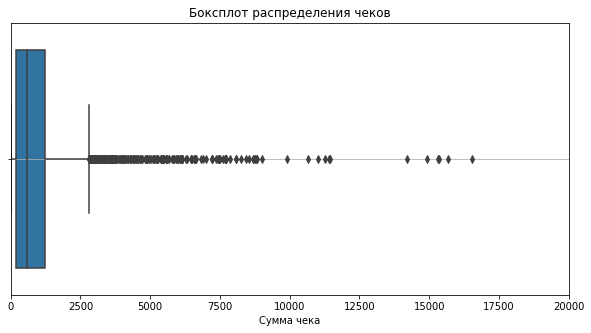

In [19]:
# построим боксплот для анализа выбросов
plt.figure(figsize=(10, 5))
sns.boxplot(x=unique_orders_data['check'])
plt.title('Боксплот распределения чеков')
plt.xlabel('Сумма чека')
plt.grid(axis='y')
plt.xlim(0, 20000)
plt.show()

В датафрейме присутствует менее 0.5% заказов с чеком более 10211.4.\
Удалим их по 99.5-перцентелю, посчитав за выбросы.

In [20]:
# сохраним 99.5-перцентиль в переменную
percentile_99_5 = np.percentile(unique_orders_data['check'], 99.5)

# смотрим информацию о таких заказах
display(len(data[data['check'] > percentile_99_5]))
display(unique_orders_data[unique_orders_data['check'] > percentile_99_5])

# смотрим количество строк в датафрейме
display(len(data))

48

,date,customer_id,order_id,product,quantity,price,check
416,2018-10-26 13:00:00,9f1e7d7d-ff10-4eb1-b596-1cbf8075aa3f,68760,Вешалка деревянная с расширенными плечиками и ...,8,262.0,22056.0
661,2018-11-06 12:00:00,1b2764ad-9151-4051-a46a-9b01b62e6335,68878,"Урна уличная ""Гео"", Hobbyka/Хоббика, 59*37,5см...",5,4874.0,24370.0
1022,2018-11-29 17:00:00,8fba3604-ef57-4b9f-b2fe-3402fa8825c8,69156,Кухонные ножницы WEBBER из нержавеющей стали с...,2,127.0,33680.0
1299,2018-12-21 16:00:00,6987e6d6-a63a-4ce2-a2d0-f424092d235e,69504,Тележка багажная DELTA ТБР-22 синий грузоподъе...,57,574.0,32718.0
1518,2019-01-15 13:00:00,58a4c3cc-504f-43ea-a74a-bae19e665552,69830,Простынь вафельная 200х180 см WELLNESS RW180-0...,27,1755.0,47385.0
1568,2019-01-22 15:00:00,6be74251-7159-4cc0-99fb-d034a17c61b0,69928,Спатифиллум Шопен d-12 см,45,250.0,11250.0
1675,2019-02-04 06:00:00,909564b8-3a5c-4d3e-8310-5ba1c837bbd7,70080,Мусорный контейнер Hailo BigBin Swing 45 0845-...,3,5512.0,16536.0
1728,2019-02-07 09:00:00,af4d270b-c7ae-4af5-9582-4e61ff08eff0,70135,"Веник сорго с деревянной ручкой с 4-мя швами, ...",20,550.0,11000.0
2969,2019-04-19 18:00:00,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71204,Салфетка Protec Textil Polyline 30х43 см Амети...,60,191.0,11460.0
2970,2019-04-19 18:00:00,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71205,Наматрацник Natures Бархатный бамбук ББ-Н-1-2 ...,12,1183.0,14196.0


5577

In [21]:
# удалим эти строки
data = data[data['check'] <= percentile_99_5]

# проверяем
display(len(data))

5529

In [22]:
# проверяем долю удаленных данных после удаления выбросов по сравнению с датафреймом без дубликатов
len_data3 = len(data)
deleted = ((len_data2 - len_data3)/len_data2) * 100
print(f'Процент удаленных данных: {deleted:.2f}%')

# проверяем долю удаленных данных после удаления выбросов по сравнению с изначальным датафреймом, еще до удаления дубликатов
len_data3 = len(data)
deleted = ((len_data - len_data3)/len_data) * 100
print(f'Процент удаленных данных: {deleted:.2f}%')

Процент удаленных данных: 0.86%
Процент удаленных данных: 26.02%


На этапе предобработки данных было удалено 26.02% данных от исходного датафрейма (учитывая долю удаленных строк-дубликатов) или 0.86% данных по сравнению с датафреймом без дубликатов.

#### Вывод

На этапе предобработки было сделано следующее:
- был изменен тип данных столбца date на datetime;
- пропусков и явных дубликатов обнаружено не было;
- были обнаружены и удалены неявные дубликаты, которые скорее всего возникли в результате сбоя (26.02% данных);
- добавлен столбец check с итоговой стоимостью заказа (чеком);
- были обнаружены и удалены выбросы по 99.5-му перцентелю столбца чека за покупки(0.86% данных).

### Исследовательский анализ данных

#### Временной период

In [23]:
# узнаем минимальную и максимальную даты
min_date = data['date'].min()
max_date = data['date'].max()
print(f'Минимальная дата: {min_date}')
print(f'Максимальная дата: {max_date}')
# а также доступный для исследования период
print(f'Доступный для исследования период: {(max_date-min_date).days} дней')

Минимальная дата: 2018-10-01 00:00:00
Максимальная дата: 2020-01-31 15:00:00
Доступный для исследования период: 487 дней


#### Основные показатели интернет-магазина

In [24]:
# выводим для наглядности общую таблицу
display(data.head())
print()

# выводим таблицу с датой, айди покупателя, айди заказа и чеком за заказ
display(order_summary.head())

,date,customer_id,order_id,product,quantity,price,check
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0,1037.0
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0,1037.0
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0,1037.0
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0,1037.0
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0,1037.0


,date,customer_id,order_id,check
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,1037.0
1,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,824.0
2,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,269.0
3,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,674.0
4,2018-10-01 11:00:00,161e1b98-45ba-4b4e-8236-e6e3e70f6f7c,68483,820.0


##### Динамика выручки в разрезе по месяцам

In [25]:
# добавим столбец с датой в виде года и месяца для каждого заказа
order_summary['year_month'] = order_summary['date'].dt.strftime('%Y-%m')
display(order_summary.head())

,date,customer_id,order_id,check,year_month
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,1037.0,2018-10
1,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,824.0,2018-10
2,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,269.0,2018-10
3,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,674.0,2018-10
4,2018-10-01 11:00:00,161e1b98-45ba-4b4e-8236-e6e3e70f6f7c,68483,820.0,2018-10


In [26]:
# считаем выручку по месяцам
revenue = order_summary.groupby('year_month')['check'].sum().reset_index().round(2)
revenue = revenue.rename(columns={'check': 'revenue'})
revenue['revenue'] = round(revenue['revenue']/1000, 2) # переведем в тысячи
display(revenue)

,year_month,revenue
0,2018-10,420.75
1,2018-11,371.18
2,2018-12,402.77
3,2019-01,284.72
4,2019-02,345.45
5,2019-03,320.02
6,2019-04,381.92
7,2019-05,306.74
8,2019-06,1086.68
9,2019-07,276.55


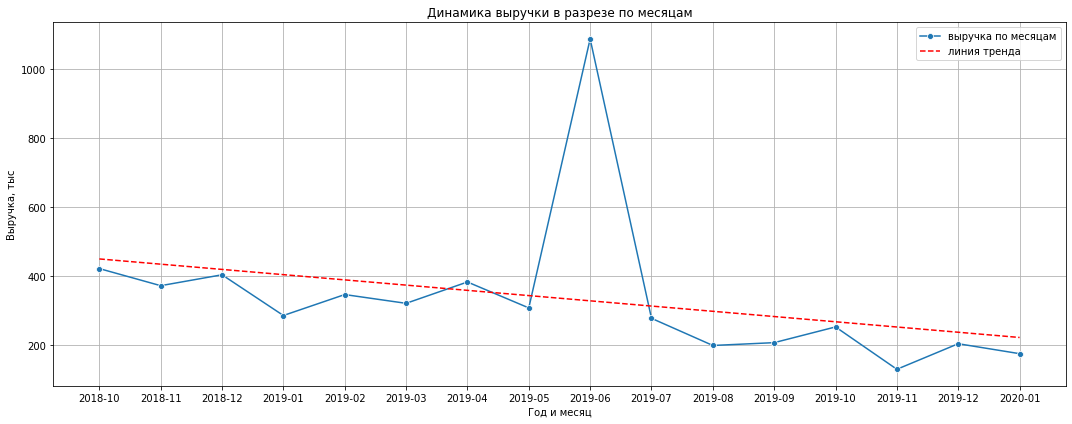

In [27]:
# строим линейный график динамики выручки в разрезе по месяцам
plt.figure(figsize=(15, 6))
sns.lineplot(data=revenue, x='year_month', y='revenue', marker='o', label='выручка по месяцам')

# добавим линию тренда
x = np.array(range(len(revenue))).reshape(-1, 1)  # индексы как x
y = revenue['revenue'].values  # значения выручки как y
model = LinearRegression().fit(x, y)
trend = model.predict(x)
plt.plot(revenue['year_month'], trend, color='r', linestyle='--', label='линия тренда')

# оформляем график
plt.xlabel('Год и месяц')
plt.ylabel('Выручка, тыс')
plt.title('Динамика выручки в разрезе по месяцам')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

По графику наглядно видно, что размер выручки постепенно снижается (линия тренда), начиная с октября 2018 года, хотя и есть резкий пик в 06.2019.\
Максимальный размер выручки был зафиксирован 06.2019. Минимальный - 11.2019 г.

##### Средний чек и его динамика в разрезе по месяцам

In [28]:
# считаем средний чек за все время
avg_check = order_summary['check'].median()
print(f'Медианный чек за весь период составляет: {avg_check}')
print()

# считаем средний чек в разрезе по месяцам
avg_check_m = order_summary.groupby('year_month')['check'].median().reset_index()
avg_check_m = avg_check_m.rename(columns={'check': 'avg_check'})
display(avg_check_m)

Медианный чек за весь период составляет: 607.5



,year_month,avg_check
0,2018-10,1012.0
1,2018-11,750.0
2,2018-12,712.0
3,2019-01,674.0
4,2019-02,635.0
5,2019-03,644.5
6,2019-04,666.5
7,2019-05,899.0
8,2019-06,1087.0
9,2019-07,614.0


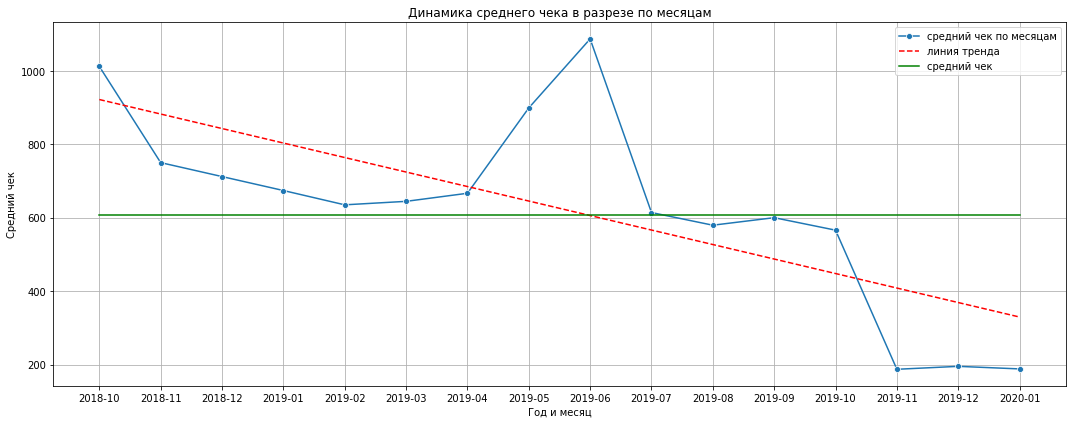

In [29]:
# строим линейный график динамики среднего чека в разрезе по месяцам 
plt.figure(figsize=(15, 6))
sns.lineplot(data=avg_check_m, x='year_month', y='avg_check', marker='o', label='средний чек по месяцам')

# добавим линию тренда
x = np.array(range(len(avg_check_m))).reshape(-1, 1)  # индексы как x
y = avg_check_m['avg_check'].values  # значения выручки как y
model = LinearRegression().fit(x, y)
trend = model.predict(x)
plt.plot(avg_check_m['year_month'], trend, color='r', linestyle='--', label='линия тренда')

# добавим линию среднего чека за весь период
plt.plot(avg_check_m['year_month'], [avg_check] * len(avg_check_m), color='g', linestyle='-', label='средний чек')

# оформляем график
plt.xlabel('Год и месяц')
plt.ylabel('Средний чек')
plt.title('Динамика среднего чека в разрезе по месяцам')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Средний чек за весь период равен 607.5.\
С начала исследуемого периода средний чек продолжает снижаться. Однако в период с января 2019 по октябрь 2019 года он держался примерно на одном уровне с резким повышением с 04.2019 и последующим снижением по 07.2019.\
Максимум среднего чека был отмечен в июне 2019 года, минимум - в ноябре 2019 г.

##### Помесячная динамика средней выручки с покупателя

In [30]:
display(order_summary.head())

,date,customer_id,order_id,check,year_month
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,1037.0,2018-10
1,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,824.0,2018-10
2,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,269.0,2018-10
3,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,674.0,2018-10
4,2018-10-01 11:00:00,161e1b98-45ba-4b4e-8236-e6e3e70f6f7c,68483,820.0,2018-10


In [31]:
# создаем промежуточную таблицу - помесячная сумма выручки с каждого покупателя
avg_revenue = order_summary.groupby(['customer_id', 'year_month'])['check'].sum().reset_index()
avg_revenue = avg_revenue.rename(columns={'check': 'revenue'})

# считаем среднюю помесячную выручку с покупателя в разрезе по месяцам
avg_revenue_cust = avg_revenue.groupby('year_month')['revenue'].median().reset_index()
display(avg_revenue_cust)

# считаем среднюю выручку с покупателя за все время
avg_revenue_c = avg_revenue['revenue'].median()
print(f'Средняя выручка с покупателя за весь период составляет: {avg_revenue_c}')

,year_month,revenue
0,2018-10,1012.0
1,2018-11,972.0
2,2018-12,886.0
3,2019-01,742.0
4,2019-02,667.0
5,2019-03,727.0
6,2019-04,714.0
7,2019-05,954.0
8,2019-06,704.0
9,2019-07,697.0


Средняя выручка с покупателя за весь период составляет: 604.5


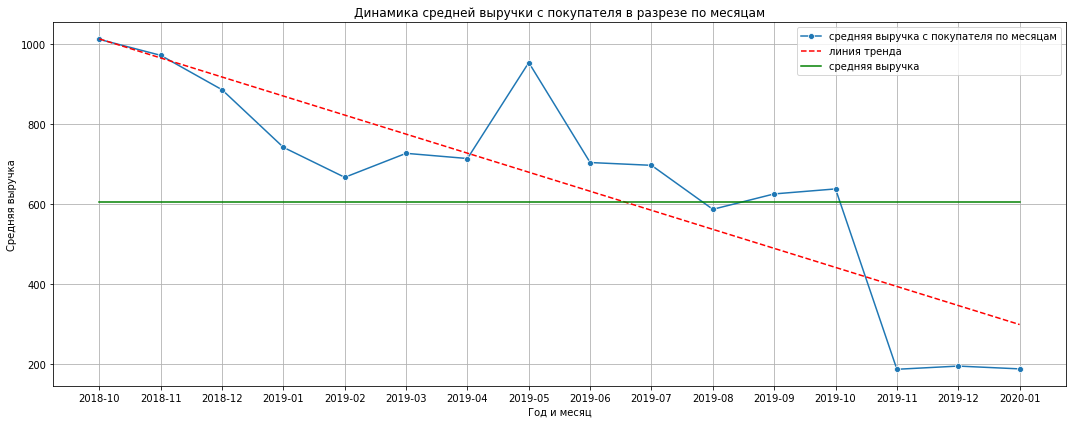

In [32]:
# строим линейный график динамики средней выручки с покупателя в разрезе по месяцам 
plt.figure(figsize=(15, 6))
sns.lineplot(data=avg_revenue_cust, x='year_month', y='revenue', marker='o', label='средняя выручка с покупателя по месяцам')

# добавим линию тренда
x = np.array(range(len(avg_revenue_cust))).reshape(-1, 1)  # индексы как x
y = avg_revenue_cust['revenue'].values  # значения выручки как y
model = LinearRegression().fit(x, y)
trend = model.predict(x)
plt.plot(avg_revenue_cust['year_month'], trend, color='r', linestyle='--', label='линия тренда')

# добавим линию средней выручки с покупателя за весь период
plt.plot(avg_revenue_cust['year_month'], [avg_revenue_c] * len(avg_revenue_cust), color='g', linestyle='-', label='средняя выручка')

# оформляем график
plt.xlabel('Год и месяц')
plt.ylabel('Средняя выручка')
plt.title('Динамика средней выручки с покупателя в разрезе по месяцам')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Средняя выручка с покупателя за весь период равна 604.5.\
График динамики средней выручки с покупателя в разрезе по месяцам примерно повторяет график динамики среднего чека.\
Заметна тенденция снижения средней выручки с покупателя, начиная с октября 2018 года. Однако с февраля 2019 по октябрь 2019 гг она держалась примерно на одном уровне, кроме резкого роста в мае 2019.\
Максимум наблюдался в октябре 2018, минимум - в ноябре 2019 года.

##### Вывод

Начиная с октября 2018 года, основные показатели интернет-магазина, такие как помесячная выручка, средний чек и помесячная средняя выручка с покупателя, демонстрируют снижение по месяцам. Минимумы за исследуемый период были достигнуты в ноябре 2019 года.\
Однако показатель среднего чека держался примерно на одном уровне в период с января по октябрь 2019г, а средней выручки с покупателя - с февраля по октябрь того же года. При этом наблюдался резкий пик по показателю средней выручки в мае 2019 года, а среднего чека в июне 2019 года (с 04.2019 и последующим снижением по 07.2019).\
Средний чек за весь период составил 607.5.\
Средняя выручка с покупателя за весь период составила 604.5.

#### Категоризация товаров

In [33]:
display(data.head())

,date,customer_id,order_id,product,quantity,price,check
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.0,1037.0
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.0,1037.0
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.0,1037.0
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.0,1037.0
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.0,1037.0


In [34]:
# приводим к одному виду
data['product'] = data['product'].str.lower()

# смотрим какие наименования есть в датафрейме
print(data['product'].unique().tolist())

['комнатное растение в горшке алое вера, d12, h30', 'комнатное растение в горшке кофе арабика, d12, h25', 'радермахера d-12 см h-20 см', 'хризолидокарпус лутесценс d-9 см', 'циперус зумула d-12 см h-25 см', 'шеффлера лузеана d-9 см', 'юкка нитчатая d-12 см h-25-35 см', 'настенная сушилка для белья gimi brio super 100', 'таз пластмассовый 21,0 л круглый "водолей" с614, 1404056', 'чехол для гладильной доски colombo persia beige 130х50 см из хлопка 5379', 'вешалка для брюк металлическая с резиновым покрытием 26 см цвет: синяя, attribute, ahs331', 'сушилка для белья потолочная zalger lift basic 1520 200 см, 10 м', 'чехол eurogold clean basic хлопок для досок 120х38-120х42 см c42', 'крючок одежный 2-х рожковый серый металлик с полимерным покрытием *тонар*, 1110027', 'корзина мягкая пластиковая 17 л, м-пластика, m2880', 'мини-сковорода marmiton "сердце" с антипригарным покрытием 12 см, lg17085', 'сковорода алюминиевая с антипригарным покрытием marble alpenkok d = 26 см ak-0039a/26n', 'стекля

In [35]:
# узнаем их количество
data['product'].nunique()

2316

Так как их слишком много, попробуем выделить первые несколько слов в наименованиях товаров, а их уже потом расписать в списки для категоризации.

In [36]:
#создадим пустой список
name = []    

#с помощью регулярного выражения выделим из столбца `product` первые несколько слов до цифры, заглавной или латинской буквы
for values in data['product']:
    name.append(re.search("[А-я][^А-Я0-9,a-zA-Z(d]*", values)[0])

data['name'] = name
# смотрим результат
display(data.head())

,date,customer_id,order_id,product,quantity,price,check,name
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.0,1037.0,комнатное растение в горшке алое вера
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.0,1037.0,комнатное растение в горшке кофе арабика
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.0,1037.0,радермахера
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.0,1037.0,хризолидокарпус лутесценс
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.0,1037.0,циперус зумула


In [37]:
# смотрим количество получившихся уникальных наименований и выводим их
names = data['name'].value_counts().reset_index()
print(len(names))
display(names['index'].tolist())

1444


['пеларгония зональная диам. ',
 'пеларгония розебудная ',
 'томата ',
 'сумка-тележка хозяйственная ',
 'сумка-тележка ',
 'герань домашняя ',
 'тележка багажная ',
 'петуния ',
 'таз пластмассовый ',
 'чехол для гладильной доски ',
 'сушилка для белья потолочная лиана ',
 'сушилка для белья ',
 'гладильная доска ',
 'пеларгония ',
 'калибрахоа ',
 'штора для ванной комнаты ',
 'гладильная доска ника ',
 'петуния махровая рассада однолетних цветов в кассете по ',
 'сушилка для белья потолочная лиана люкс ',
 'полки ',
 'рассада томата ',
 'пеларгония зональная махровая лососевая',
 'сушилка для белья напольная ника сб',
 'пеларгония зональная ринго вайт ',
 'сушилка для белья потолочно-настенная ',
 'однолетнее растение петуния махровая в кассете ',
 'сушилка для белья настенная ',
 'коврик придверный ',
 'стремянка ',
 'салатник ',
 'декабрист в горшке ',
 'скатерть ',
 'фуксия ',
 'сушилка для белья лиана люкс ',
 'чехол для одежды ',
 'пеларгония зональная мультиблум скарлет ай ',


Выделим следующие категории товаров:
- товары для дома и декор (home): освещение, мебель, декор, техника и т.д.
- товары для дачи (dacha): рассада, растения, 
- товары для кухни(kitchen): посуда, скатерти, губки
- другое (other): сумки, тележки, товары для ремонта

In [38]:
# создадим списки с ключевыми словами
home = ['коврик', 'светильник', 'крючок', 'насадка', 'гладильная', 'сушилка', 'чехол', 'таз', 'корзина', 'унитазный', 'плечики', 
        'рукав', 'вешалка-плечики', 'подрукавник', 'сиденье','зубная', 'гладильной', 'тряпкодержатель', 'штора', 'муляж',
        'карниз', 'полки', 'штанга', 'искусственная', 'искусственный', 'композиция', 'одеяло', 'полотенце',
        'швабра', 'вербена', 'подставка', 'окномойка', 'мусорный контейнер','плед', 'щетка', 'средство', 'ванной', 'салфеток', 
        'термометр', 'дозатор', 'комод', 'этажерка', 'веник','ящик', 'вешалка-сушилка', 'вешалок', 'для мусора', 'декоративная',
        'подголовник', 'мыло', 'сетка для глажения', 'картина', 'кофр', 'пружина', 'наматрацник', 'пододеяльник',
        'прищепок', 'прищепки', 'гель', 'совок','полка', 'весы', 'кольца', 'сетка для стирки', 'стеллаж','подушка', 
        'коробка', 'вантуз', 'халат', 'ведро', 'наматрасник', 'паста зубная', 'ёрш', 'для мытья', 'пылесос', 'пробка',
         'постельного','простынь', 'ложка обувная', 'бак для белья', 'ерша', 'табак', 'наволочка',  'ерш',
        'покрывало', 'щетка-утюжок', 'ваза',  'наматрицник-чехол', 'стиральный', 'ручка', 'отжим', 'ванна',
         'стирки', 'короб', 'ткань', 'вешалка-стойка', 'шпингалет', 'пуф', 'простыня', 'фен', 'вешалка', 'ковёр',
         'фоторамка', 'ковер', 'чистящий', 'для ванн', 'вешалки', 'утюг', 'паста для полировки', 'держатель', 'одежды', 'ролика', 'тряпка',
        'постельное', 'отбеливатель', 'корзинка', 'ванну', 'посудомоечных', 'полотенец', 'тряпки', 'обувница', 'скребок для окон'
]

dacha = ['пеларгония', 'сорт', 'герань', 'тележка', 'петуния', 'калибрахоа', 'рассада','растение', 'декабрист', 
    'фуксия', 'циперус', 'эвкалипт', 'пуансеттия','фиалка', 'бальзамин', 'примула', 'дерево', 'кашпо', 'бакопа','мята', 
         'корыто', 'хлорофитум', 'бегония', 'цикламен', 'мирт', 'котовник',  'настурция', 'садовая', 'арбуз', 'лилейник',
         'базилик', 'овсянница', 'вербейник', 'афеляндра', 'колокольчик', 'лаванда', 'алоэ вера', 'дыня', 'незабудка',
         'миска', 'укроп', 'мимоза','зверобой', 'гардения', 'антуриум', 'тимьян', 'гвоздика', 'аптения', 'лобелия', 'мединилла',
          'седум','эхеверия', 'эхинокактус', 'вербена', 'калатея', 'в горшке', 'в кассете','ранункулус', 'ясколка', 'нивянник', 
          'розмарин','томат', 'кореопсис', 'роза', 'физостегия', 'клубника',  'флокс', 'гипсофила', 'перчатки', 'эхинацея',
         'бидон', 'обыкновенная', 'лопатка', 'урна', 'd-12', 'd-9', 'd-5', 'd-10', 'космея', 'цинния', 'пиретрум', 'нолина',
         'd-13', 'энотера', 'бархатцы', 'd-15', 'хризантема', 'd-21', 'тюльпан', 'd-7', 'платикодон', 'виола', 'календула',
         'гиностемма', 'd-17', 'кипарисовик', 'морковь', 'огурец', 'салат', 'годеция', 'лапчатка', 'цинерария', 'эшшольция',
         'петрушка', 'лен', 'камнеломка', 'ель', 'd-19', 'черенок', 'дендробиум', 'горох', 'земляника','георгина', 'смолевка',
         'h-20', 'калла', 'вероника', 'хоста', 'гайлардия', 'монарда', 'рудбекия', 'барвинок', 'аквилегия', 'алиссум', 'астра', 'солидаго',
         'бадан', 'лаватера', 'анемона'        
]

kitchen = ['сковорода', 'крышка', 'салатник', 'скатерть', 'тарелка', 'вилка','чайник', 'банка', 'салфетка', 'овощеварка', 'терка',
    'чайный набор', 'ножей', 'кувшин', 'тepмокружка','термос', 'лоток', 'просеиватель', 'контейнер для продуктов', 'контейнер для свч', 
           'измельчитель', 'ложка столовая', 'хлебница', 'столовых', 'блюдо', 'кухонные', 'разделочная доска', 'нож','набор форм', 
            'соковыжималка', 'миксер', 'сито', 'вкладыши для хранения посуды', 'кастрюля', 'кружка', 'пакет', 'салфетница', 'отделитель',
            'пьезозажигалка', 'ковш', 'рыбочистка', 'стакан', 'масленка', 'щетка для посуды', 'сотейник', 'для выпечки', 'соковарка', 
           'сахарница', 'емкость для свч', 'орехоколка', 'ложка чайная',  'салатников', 'термостакан', 'набор стаканов', 'венчик', 'миска', 
            'набор кружек', 'половник', 'набор бокалов',  'дуршлаг', 'набор посуды', 'электроштопор', 'ложка кухонная',
           'пресс', 'набор фужеров', 'мини-сковорода', 'котел', 'толкушка', 'противень', 'салфетки', 'контейнер для приготовления',
           'столовая ложка', 'чайная ложка', 'овощечистка', 'блюдце', 'губка', 'антижир', 'кухонных', 'мантоварка', 'доска разделочная',
           'кондитерский', 'кипятильник', 'картофелемялка', 'набор для пикника', 'газовую плиту', 'бульонница', 'контейнер герметичный',
           'емкость для соуса', 'скалка', 'тортница'
]

other = [ 'стремянка', 'лестница-стремянка','сумка', 'сумка-тележка', 'щетка-сметка', 'тележка', 'стремянки', 'стяжка', 'бензин', 'шнур',
           'линейка', 'петля', 'штангенциркуль', 'лестница', 'сварка',  'фал', 'сверло-фреза', 'стремянка-табурет', 'крепеж', 'шпагат',  
          'сметка', 'шило', 'измерительный угольник', 'набор инструментов', 'мешок для строительного мусора', 'набор сверел', 
          'основание для пробки', 'увлажняющая маска', 'решетка вентиляционная', 'завертка форточная', 'уголок оконный', 'инструмент',
          'напильников', 'сверло', 'фиксатор-шар'   
]

In [39]:
# прогнали через проверку все списки для исключния дублей
home = pd.Series(home)
value_counts = home.value_counts()
repeated_values = value_counts[value_counts > 1]
print(repeated_values)

Series([], dtype: int64)


In [40]:
# создаем функцию, которая будет присваивать категорию товара каждой строке в зависимости от ключевых слов 
def classify_product(product):
    for item in kitchen:
        if item in product:
            return 'товары для кухни'
    for item in home:
        if item in product:
            return 'товары для дома'
    for item in dacha:
        if item in product:
            return 'товары для дачи'
    for item in other:
        if item in product:
            return 'другое'    
    return 'нет данных о категории'

In [41]:
# применим функцию к датафрейму
data['product_category'] = data['product'].apply(classify_product)
# смотрим, что сработало правильно
display(data.head())

,date,customer_id,order_id,product,quantity,price,check,name,product_category
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.0,1037.0,комнатное растение в горшке алое вера,товары для дачи
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.0,1037.0,комнатное растение в горшке кофе арабика,товары для дачи
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.0,1037.0,радермахера,товары для дачи
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.0,1037.0,хризолидокарпус лутесценс,товары для дачи
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.0,1037.0,циперус зумула,товары для дачи


In [42]:
# проверим, что нераспределенных товаров не осталось
display(data.query('product_category == "нет данных о категории"'))

,date,customer_id,order_id,product,quantity,price,check,name,product_category


In [43]:
# уберем лишний столбец name
data = data.drop('name', axis=1)
# проверим
display(data.head())

,date,customer_id,order_id,product,quantity,price,check,product_category
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.0,1037.0,товары для дачи
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.0,1037.0,товары для дачи
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.0,1037.0,товары для дачи
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.0,1037.0,товары для дачи
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.0,1037.0,товары для дачи


товары для дачи     3135
товары для дома     1785
товары для кухни     506
другое               103
Name: product_category, dtype: int64

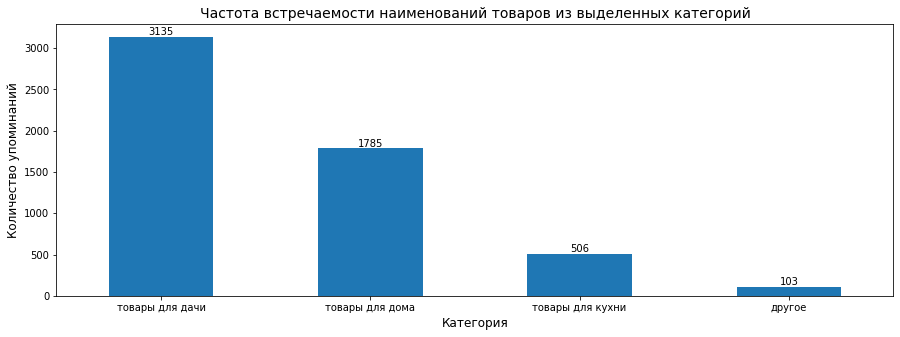

In [44]:
# посмотрим, наименования товаров какой категории чаще встречаются в датафрейме
products = data['product_category'].value_counts()
display(products)

# строим вертикальную столбчатую диаграмму
products.plot(kind='bar', figsize=(15,5), rot=0, legend=False)
plt.title('Частота встречаемости наименований товаров из выделенных категорий', fontsize=14)
plt.ylabel('Количество упоминаний', fontsize=12)
plt.xlabel('Категория', fontsize=12)
for index, value in enumerate(products):
    plt.text(index, value, str(value), ha='center', va='bottom') 
plt.show()

Было выделено 4 категории товаров: товары для дома, для дачи, для кухни и другое.\
Самая популярная категория - товары для дачи (их наименования встречаются в заказах 3135 раз), реже всего встречаются наименования товаров категории "другое" (103).

#### Сегментация пользователей

Проведем сегментацию пользователей по их покупкам с помощью RFM-анализа:
- R - количество дней с последней покупки
- F - общее количество покупок
- M - общая сумма покупок

In [45]:
# определим дату анализа как максимум из дат покупок плюс один день
analysis_date = data['date'].max() + pd.DateOffset(days=1)

# создаем сводную таблицу с информацие о давности последней покупки покупателя, количестве заказов(частоте) и сумме заказов
rfm = data.groupby('customer_id').agg({
    'date': lambda x: (analysis_date - x.max()).days,  # давность
    'order_id': 'count',         # частота
    'check': 'sum'        # общая сумма
}).rename(columns={
    'date': 'recency',
    'order_id': 'frequency',
    'check': 'monetary'
})

# проверим
display(rfm.head())

,recency,frequency,monetary
customer_id,,,
000d6849-084e-4d9f-ac03-37174eaf60c4,108,4,2220.0
001cee7f-0b29-4716-b202-0042213ab038,350,1,442.0
00299f34-5385-4d13-9aea-c80b81658e1b,109,1,914.0
002d4d3a-4a59-406b-86ec-c3314357e498,369,1,1649.0
003bbd39-0000-41ff-b7f9-2ddaec152037,124,1,2324.0


In [46]:
# разделим каждый столбец на 3 группы в зависимости от показателей покупателя
rfm['recency_score'] = pd.cut(rfm['recency'], bins=3, labels=[3, 2, 1])  # чем меньше дней, тем выше оценка
rfm['frequency_score'] = pd.cut(rfm['frequency'], bins=3, labels=[1, 2, 3])  # чем больше покупок(частота), тем выше оценка
rfm['monetary_score'] = pd.cut(rfm['monetary'], bins=3, labels=[1, 2, 3])  # чем больше сумма, тем выше оценка
# смотрим
display(rfm)

,recency,frequency,monetary,recency_score,frequency_score,monetary_score
customer_id,,,,,,
000d6849-084e-4d9f-ac03-37174eaf60c4,108,4,2220.0,3,1,1
001cee7f-0b29-4716-b202-0042213ab038,350,1,442.0,1,1,1
00299f34-5385-4d13-9aea-c80b81658e1b,109,1,914.0,3,1,1
002d4d3a-4a59-406b-86ec-c3314357e498,369,1,1649.0,1,1,1
003bbd39-0000-41ff-b7f9-2ddaec152037,124,1,2324.0,3,1,1
...,...,...,...,...,...,...
ff601403-b094-4b86-9ac6-264d725b9277,13,2,1739.0,3,1,1
ffaeab76-3a8d-49ee-860f-17273b2fc8a2,94,1,397.0,3,1,1
ffb5976a-7a4d-460b-95c4-5ffaba31cb24,413,1,389.0,1,1,1


In [47]:
# добавим вспомогательный столбец, где будут записаны все три оценки
rfm['score'] = rfm[['recency_score', 'frequency_score', 'monetary_score']].apply(lambda row: row.tolist(), axis=1)
rfm['score'] = rfm['score'].apply(lambda x: ''.join(map(str, x)))
display(rfm)

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,score
customer_id,,,,,,,
000d6849-084e-4d9f-ac03-37174eaf60c4,108,4,2220.0,3,1,1,311
001cee7f-0b29-4716-b202-0042213ab038,350,1,442.0,1,1,1,111
00299f34-5385-4d13-9aea-c80b81658e1b,109,1,914.0,3,1,1,311
002d4d3a-4a59-406b-86ec-c3314357e498,369,1,1649.0,1,1,1,111
003bbd39-0000-41ff-b7f9-2ddaec152037,124,1,2324.0,3,1,1,311
...,...,...,...,...,...,...,...
ff601403-b094-4b86-9ac6-264d725b9277,13,2,1739.0,3,1,1,311
ffaeab76-3a8d-49ee-860f-17273b2fc8a2,94,1,397.0,3,1,1,311
ffb5976a-7a4d-460b-95c4-5ffaba31cb24,413,1,389.0,1,1,1,111


Распределим покупателей на три сегмента на основе оценок столбца score:
- ушедшие покупатели. Для них будут характерны следующие коды (сочетания оценок): 111, 112, 113, 121, 122, 123, 131, 132, 133
- неактивные покупатели (211, 212, 213, 221, 222, 223, 231, 232, 233)
- постоянные покупатели (311, 312, 313, 321, 322, 323, 331, 332, 333)

In [48]:
# создадим списки с кодами для трех сегментов

lost = ['111', '112', '113', '121', '122', '123', '131', '132', '133']

inactive = ['211', '212', '213', '221', '222', '223', '231', '232', '233']

permanent = ['311', '312', '313', '321', '322', '323', '331', '332', '333']

In [49]:
# создаем функцию, которая будет распределять покупателей на сегменты
def classify_customer(customer):
    for score in lost:
        if score in customer:
            return 'Ушедшие покупатели'
    for score in inactive:
        if score in customer:
            return 'Неактивные покупатели'
    for score in permanent:
        if score in customer:
            return 'Постоянные покупатели'    
    return 'нет данных'  

# применим функцию к датафрейму
rfm['group'] = rfm['score'].apply(classify_customer)
# смотрим, что сработало правильно
display(rfm.head())

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,score,group
customer_id,,,,,,,,
000d6849-084e-4d9f-ac03-37174eaf60c4,108,4,2220.0,3,1,1,311,Постоянные покупатели
001cee7f-0b29-4716-b202-0042213ab038,350,1,442.0,1,1,1,111,Ушедшие покупатели
00299f34-5385-4d13-9aea-c80b81658e1b,109,1,914.0,3,1,1,311,Постоянные покупатели
002d4d3a-4a59-406b-86ec-c3314357e498,369,1,1649.0,1,1,1,111,Ушедшие покупатели
003bbd39-0000-41ff-b7f9-2ddaec152037,124,1,2324.0,3,1,1,311,Постоянные покупатели


In [50]:
# уберем лишние столбцы
rfm = rfm.drop(['recency', 'frequency', 'monetary','recency_score', 'frequency_score', 'monetary_score', 'score'], axis=1)
# проверим
display(rfm.head())

,group
customer_id,
000d6849-084e-4d9f-ac03-37174eaf60c4,Постоянные покупатели
001cee7f-0b29-4716-b202-0042213ab038,Ушедшие покупатели
00299f34-5385-4d13-9aea-c80b81658e1b,Постоянные покупатели
002d4d3a-4a59-406b-86ec-c3314357e498,Ушедшие покупатели
003bbd39-0000-41ff-b7f9-2ddaec152037,Постоянные покупатели


С помощью RFM-анализа покупатели были распределены на три сегмента на основе данных о их покупках:
- ушедшие покупатели, которые покупали единоразово и на небольшие суммы или давно не покупали
- неактивные покупатели, это относительно недавние клиенты, которые пришли единоразово, или те, которые покупали часто, но по какой-то причине перестали 
- постоянные покупатели, это покупатели, которые покупали недавно, или которые покупают постоянно за любую сумму

#### Анализ сегментов пользователей

##### Количество покупателей

In [51]:
# всего уникальных покупателей
print(f'Уникальных покупателей всего: {data["customer_id"].nunique()} человек')

Уникальных покупателей всего: 2420 человек


Постоянные покупатели    1048
Ушедшие покупатели        705
Неактивные покупатели     667
Name: group, dtype: int64

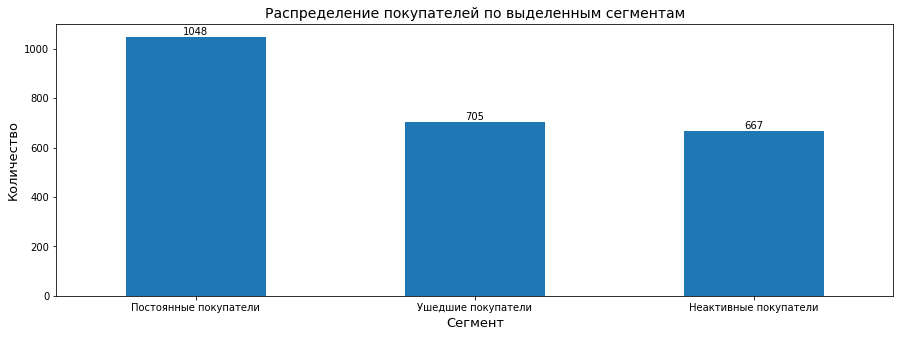

In [52]:
# посмотрим распределение покупателей по сегментам
segments = rfm['group'].value_counts()
display(segments)

# визуализируем
segments.plot(kind='bar', figsize=(15,5), rot=0, legend=False)
plt.title('Распределение покупателей по выделенным сегментам', fontsize=14)
plt.ylabel('Количество', fontsize=13)
plt.xlabel('Сегмент', fontsize=13)
for index, value in enumerate(segments):
    plt.text(index, value, str(value), ha='center', va='bottom') 
plt.show()

Всего уникальных покупателей в интернет-магазине 2420.\
Они были распределены на три сегмента на основе их покупок: давности, их количества и общей потраченной суммы.\
Больше всего покупателей в сегменте "Постоянные" - 1048 человек, это хороший показатель, так как это новые покупатели или те, которые достаточно часто и/или на хорошие суммы закупаются у нас.\
При этом ушедших покупателей достаточно много - 705 человек, стоит рассмотреть методы для их возврата.\
Неактивных покупателей около 667, это те люди, которые недавно совершали покупки, но по какой-то причине перестали, также стоит рассмотреть возможные причины и способы их возврата.

##### Средний чек по сегментам в общем и в разрезе по месяцам

In [53]:
# добавим данные о сегменте покупателя в основной датафрейм
rfm = rfm.reset_index() # для объединения по айди покупателей
data = pd.merge(data, rfm, on='customer_id', how='left')

# добавим столбец с датой в виде года и месяца
data['year_month'] = data['date'].dt.strftime('%Y-%m')

# смотрим
display(data)

,date,customer_id,order_id,product,quantity,price,check,product_category,group,year_month
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
...,...,...,...,...,...,...,...,...,...,...
5524,2020-01-30 21:00:00,63208953-a8e4-4f77-9b47-3a46e7b72eee,104002,томата (помидор) черниченский черри № 116 сорт...,2,38.0,76.0,товары для дачи,Постоянные покупатели,2020-01
5525,2020-01-30 22:00:00,d99d25f1-4017-4fcd-8d29-c580cc695a1a,107336,дендробиум санок анна грин 1 ствол d-12 см,1,869.0,869.0,товары для дачи,Постоянные покупатели,2020-01
5526,2020-01-31 02:00:00,2c9bd08d-8c55-4e7a-9bfb-8c56ba42c6d6,106336,подставка для обуви резиновая attribute 80x40 ...,1,354.0,354.0,товары для дома,Постоянные покупатели,2020-01
5527,2020-01-31 12:00:00,cdd17932-623e-415f-a577-3b31312fd0e2,102002,тагетис крупноцветковый рассада однолетних цве...,1,128.0,128.0,товары для дачи,Постоянные покупатели,2020-01


In [54]:
# перезапишем уже очищенный датафрейм с уникальными айди заказов
unique_orders_data = data.drop_duplicates(subset=['order_id'], keep='first')

In [55]:
# считаем средний чек по сегментам в общем
avg_group_check = unique_orders_data.groupby('group')['check'].median()
print(avg_group_check)
print()

# считаем средний чек по сегментам в разрезе по месяцам
avg_group_check_m = unique_orders_data.groupby(['group', 'year_month'])['check'].median().reset_index()
avg_group_check_m = avg_group_check_m.rename(columns={'check': 'avg_check'})
avg_group_check_m = avg_group_check_m.sort_values(by='year_month')
display(avg_group_check_m.head())

group
Неактивные покупатели    632.0
Постоянные покупатели    442.0
Ушедшие покупатели       749.0
Name: check, dtype: float64



,group,year_month,avg_check
24,Ушедшие покупатели,2018-10,937.0
8,Постоянные покупатели,2018-10,734.0
25,Ушедшие покупатели,2018-11,929.0
9,Постоянные покупатели,2018-11,667.5
26,Ушедшие покупатели,2018-12,734.0


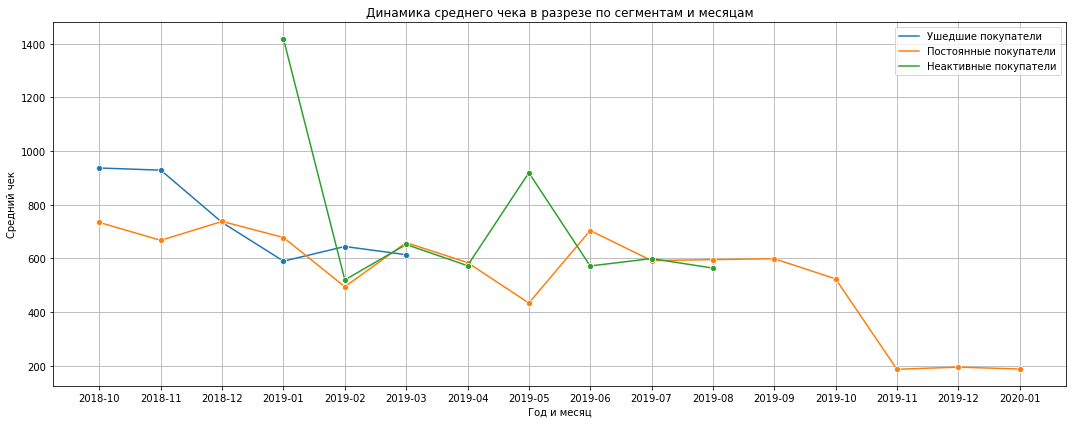

In [56]:
# строим линейный график динамики среднего чека в разрезе по сегментам и месяцам 
plt.figure(figsize=(15, 6))
sns.lineplot(data=avg_group_check_m, x='year_month', y='avg_check', hue='group',  marker='o')

# оформляем график
plt.xlabel('Год и месяц')
plt.ylabel('Средний чек')
plt.title('Динамика среднего чека в разрезе по сегментам и месяцам')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Средний чек по сегментам в общем:
- неактивные покупатели - 632.0
- постоянные покупатели - 442.0
- ушедшие покупатели - 749.0

Средний чек по сегментам в динамике: 
- у постоянных клиентов на протяжении почти всего периода средний чек был на том же уровне, что и средние чеки у других сегментов, он держался на уровне примерно 450-750, однако с 10.2019 года он за месяц снизился до минимума - около 200.
- у неактивных покупателей в 01.2019 года был самый высокий показатель среднего чека (1400), но он за месяц снизился до 500, далее он держался примерно на том же уровне, как у других сегментов. Однако в 05.2019 он вырос и снова пришел к предпиковому значению.  Период, за который известны данные о неактивных покупателях, составляет 8 месяцев (01.2019 - 08.2019).
- средний чек у ушедших покупателей снизился к 01.2019 с 950 до 600, но потом незначительно увеличился (диапазон за весь период примерно равен 600-950). Период составляет 6 месяцев (10.2018-03.2019).
- интересно то, что, когда у неактивных покупателей 05.2019 средний чек вырос, у постоянных покупателей этот показатель наоборот снизился

##### Основные продукты и категории в разрезе по сегментам пользователей

Проанализируем распределение категорий товаров в разрезе по сегментам

In [57]:
# создаем сводную таблицу с частотой встречаемости продуктов в разрезе по сегментам покупателей и категории товаров
product_cat = data.groupby(['group', 'product_category'])['product'].count().reset_index()
product_cat = product_cat.rename(columns={'product': 'cnt_products'})
product_cat = product_cat.sort_values(by=['group', 'cnt_products'], ascending=False)
display(product_cat)

,group,product_category,cnt_products
9,Ушедшие покупатели,товары для дачи,663
10,Ушедшие покупатели,товары для дома,631
11,Ушедшие покупатели,товары для кухни,214
8,Ушедшие покупатели,другое,36
6,Постоянные покупатели,товары для дома,823
5,Постоянные покупатели,товары для дачи,809
7,Постоянные покупатели,товары для кухни,221
4,Постоянные покупатели,другое,49
1,Неактивные покупатели,товары для дачи,1663
2,Неактивные покупатели,товары для дома,331


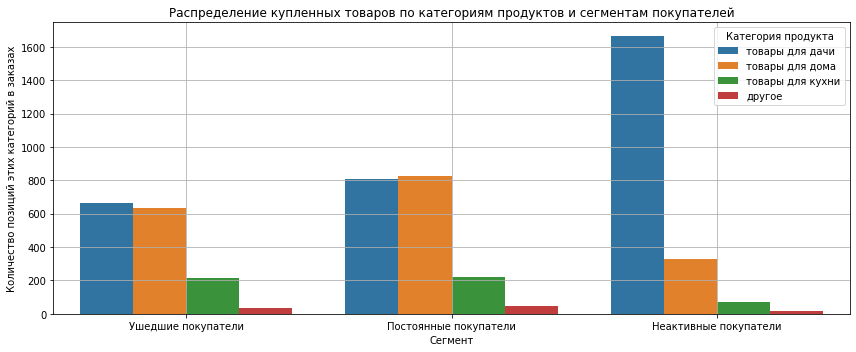

In [58]:
# построим столбчатый график 
plt.figure(figsize=(12, 5))
sns.barplot(data=product_cat, x='group', y='cnt_products', hue='product_category')
plt.title('Распределение купленных товаров по категориям продуктов и сегментам покупателей')
plt.xlabel('Сегмент')
plt.ylabel('Количество позиций этих категорий в заказах')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Категория продукта')
plt.show()

У ушедших и неактивных покупателей наиболее популярной является категория товаров для дачи, причем у неактивных покупателей она встречается в 3-4 раза чаще в данных, чем у них же категория товаров для дома, в то время как у ушедших примерно одинаково популярны товары для дома и для дачи. Скорее всего это объясняется тем, что период активности неактивных покупателей выпал на весну-лето 2019 года.\
У постоянных покупателей более популярны товары для дома, но при это разница между ними и товарами для дачи несущественна.\
Реже всего у всех сегментов пользователей встречаются заказы с товарами из категории Другое.

Проанализируем распределение продуктов в разрезе по сегментам

In [59]:
# создаем сводную таблицу с частотой встречаемости продуктов в разрезе по сегментам покупателей и наименованиям товаров
products = data.groupby(['group', 'product'])['customer_id'].count().reset_index()
products.columns = ['group', 'product_name', 'cnt_products']
products = products.sort_values(by=['cnt_products'], ascending=False)
display(products.head(30))

,group,product_name,cnt_products
406,Неактивные покупатели,пеларгония розебудная prins nikolai укорененны...,35
1458,Постоянные покупатели,пеларгония розебудная red pandora укорененный ...,27
408,Неактивные покупатели,пеларгония розебудная red pandora укорененный ...,27
387,Неактивные покупатели,пеларгония зональная диам. 12 см сиреневый пол...,27
405,Неактивные покупатели,пеларгония розебудная mary укорененный черенок,24
2742,Ушедшие покупатели,сумка-тележка 2-х колесная gimi argo синяя,21
2527,Ушедшие покупатели,пеларгония зональная диам. 12 см сиреневый пол...,21
407,Неактивные покупатели,пеларгония розебудная queen ingrid укорененный...,20
344,Неактивные покупатели,однолетнее растение петуния махровая в кассете...,19
1447,Постоянные покупатели,пеларгония зональная ринго вайт d-7 см h-10 см...,16


В топ-30 наболее популярных товаров входят в основном цветы (чаще всего разные сорта пеларгонии), сумки-тележки разных моделей и сушилка для белья потолочная.\
Посмотрим топ-5 наболее популярных товаров в разрезе по сегментам.

In [60]:
# находим топ-5 наиболее часто встречаемых наименований товаров в разрезе по сегментам
top_5_per_group = products.groupby('group').apply(lambda x: x.nlargest(5, 'cnt_products')).reset_index(drop=True)
display(top_5_per_group)

,group,product_name,cnt_products
0,Неактивные покупатели,пеларгония розебудная prins nikolai укорененны...,35
1,Неактивные покупатели,пеларгония розебудная red pandora укорененный ...,27
2,Неактивные покупатели,пеларгония зональная диам. 12 см сиреневый пол...,27
3,Неактивные покупатели,пеларгония розебудная mary укорененный черенок,24
4,Неактивные покупатели,пеларгония розебудная queen ingrid укорененный...,20
5,Постоянные покупатели,пеларгония розебудная red pandora укорененный ...,27
6,Постоянные покупатели,пеларгония зональная ринго вайт d-7 см h-10 см...,16
7,Постоянные покупатели,тележка багажная delta тбр-20 синий грузоподъе...,15
8,Постоянные покупатели,сумка-тележка 2-х колесная gimi argo синяя,12
9,Постоянные покупатели,пеларгония розебудная prins nikolai укорененны...,11


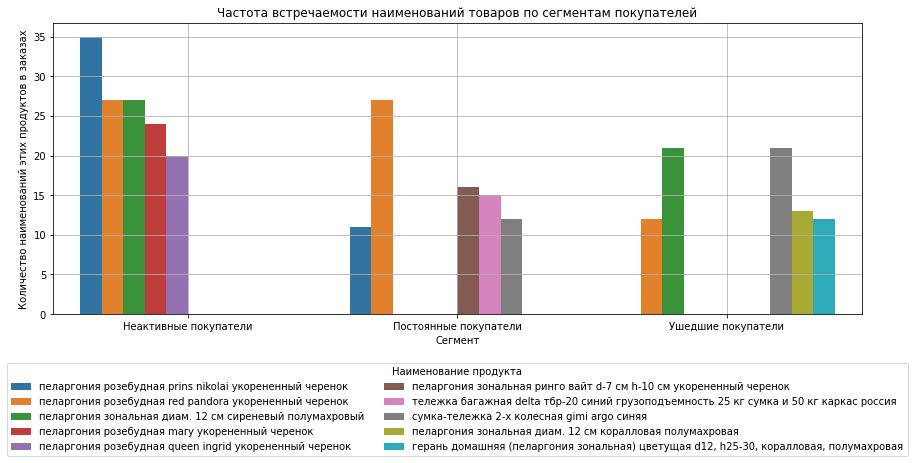

In [61]:
# построим столбчатый график 
plt.figure(figsize=(12, 5))
sns.barplot(data=top_5_per_group, x='group', y='cnt_products', hue='product_name')
plt.title('Частота встречаемости наименований товаров по сегментам покупателей')
plt.xlabel('Сегмент')
plt.ylabel('Количество наименований этих продуктов в заказах')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Наименование продукта', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()

В топ-5 наиболее часто встречаемых в заказах наименований товаров:
- у ушедших пользователей входят: 3 сорта пеларгонии, 1 сорт герани домашней и сумка-тележка
- у неактивных: 5 сортов пеларгонии
- у постоянных: 3 сорта пеларгонии, тележка багажная и сумка-тележка

Сорта пеларгонии пользуются большой популярностью у всех покупателей. Количество заказов с ними в разных сегментах колеблется от 11 до 35.\
Тележки двух видов (сумка-тележка и тележка багажная) встречаются реже (в 12-21 заказе).

##### Количество заказов в среднем у покупателей каждого сегмента

Посчитаем количество уникальных заказов у покупателей из разных сегментов

group
Постоянные покупатели    1824
Ушедшие покупатели        918
Неактивные покупатели     761
Name: order_id, dtype: int64

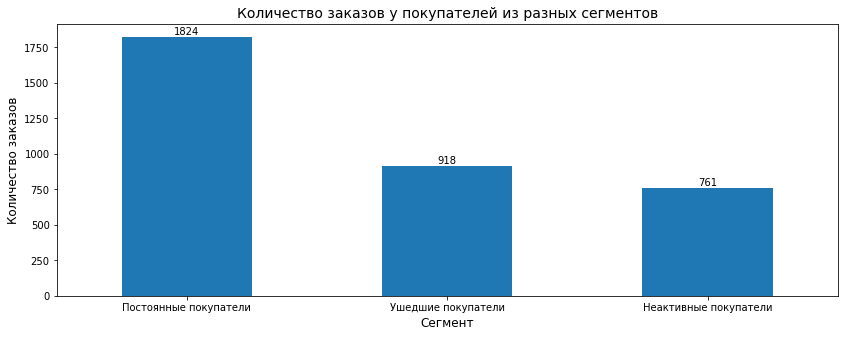

In [62]:
# считаем количество уникальных заказов по каждому сегменту
orders_count = unique_orders_data.groupby('group')['order_id'].count().round(2).sort_values(ascending=False)
display(orders_count)

# визуализируем
orders_count.plot(kind='bar', figsize=(14,5), rot=0, legend=False)
plt.title('Количество заказов у покупателей из разных сегментов', fontsize=14)
plt.ylabel('Количество заказов', fontsize=12)
plt.xlabel('Сегмент', fontsize=12)
for index, value in enumerate(orders_count):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

Теперь посчитаем количество заказов в среднем на покупателя каждого сегмента

group
Постоянные покупатели    1.74
Ушедшие покупатели       1.30
Неактивные покупатели    1.14
Name: order_id, dtype: float64

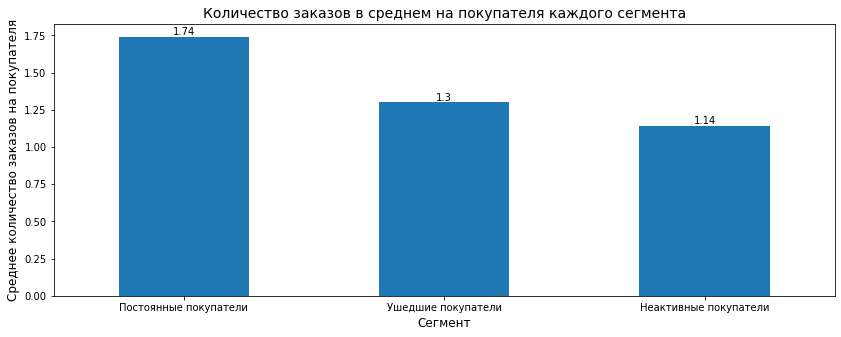

In [63]:
# считаем количество заказов у уникальных покупателей каждого сегмента
unique_orders_count = data.groupby(['customer_id', 'group'])['order_id'].nunique().reset_index()

# теперь считаем заказов в среднем на покупателя каждого сегмента
orders_avg_count = unique_orders_count.groupby('group')['order_id'].mean().round(2).sort_values(ascending=False)
display(orders_avg_count)

# визуализируем
orders_avg_count.plot(kind='bar', figsize=(14,5), rot=0, legend=False)
plt.title('Количество заказов в среднем на покупателя каждого сегмента', fontsize=14)
plt.ylabel('Среднее количество заказов на покупателя', fontsize=12)
plt.xlabel('Сегмент', fontsize=12)
for index, value in enumerate(orders_avg_count):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

Больше всего заказов было сделано покупателями из сегмента "Постоянные" (1824), у ушедших покупателей 918 заказов, а у неактивных - 761.\
В среднем на любого покупателя приходится от 1.14-1.74 заказа: наивысший показатель у постоянных посетителей (1.74), а наименьший у неактивных (1.14), у ушедших примерно 1.3 заказа в среднем.

##### Выручка с покупателей в разрезе по сегментам

,total_amount_mln
group,
Постоянные покупатели,1.64
Ушедшие покупатели,1.10
Неактивные покупатели,0.82


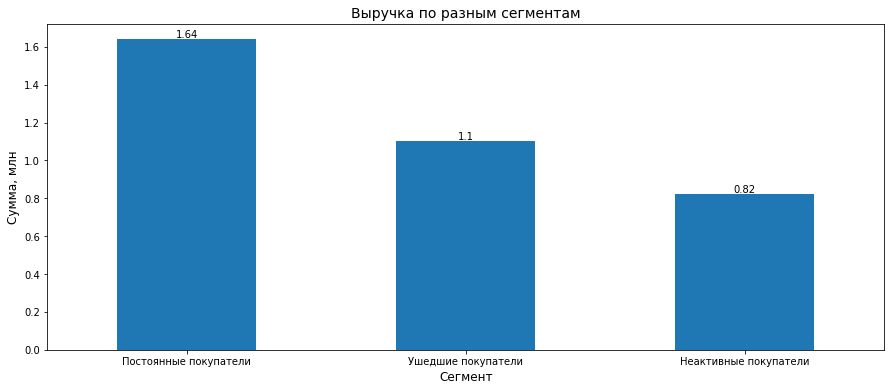

In [64]:
# считаем выручку по каждому сегменту
revenue_group = unique_orders_data.groupby('group')['check'].sum().reset_index()
revenue_group = revenue_group.rename(columns={'check': 'total_amount_mln'})
revenue_group['total_amount_mln'] = round(revenue_group['total_amount_mln']/1000000, 2)    # переведем суммы в млн
revenue_group = revenue_group.sort_values(by='total_amount_mln', ascending=False)
revenue_group = revenue_group.set_index('group')
display(revenue_group)

# визуализируем
revenue_group.plot(kind='bar', figsize=(15,6), rot=0, legend=False)
plt.title('Выручка по разным сегментам', fontsize=14)
plt.ylabel('Сумма, млн', fontsize=12)
plt.xlabel('Сегмент', fontsize=12)
for index, value in enumerate(revenue_group['total_amount_mln']):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

Больше всего выручки принесли магазину постоянные покупатели (1.64 млн), меньше всего - неактивные покупатели (0.82 млн); ушедшие покупатели сделали заказов на 1.1 млн.\
(наверно этот показатель и подобные стоит считать не по датафрейму, где мы обрезали выбросы)

##### Вывод

Всего уникальных покупателей в интернет-магазине 2420.\
Всего уникальных покупателей в интернет-магазине 2420.\
Они были распределены на три сегмента на основе их покупок: давности, их количества и общей потраченной суммы.\
Больше всего покупателей в сегменте "Постоянные" - 1048 человек, это хороший показатель, так как это новые покупатели или те, которые достаточно часто и/или на хорошие суммы закупаются у нас.\
При этом ушедших покупателей достаточно много - 705 человек, стоит рассмотреть методы для их возврата.\
Неактивных покупателей около 667, это те люди, которые недавно совершали покупки, но по какой-то причине перестали, также стоит рассмотреть возможные причины и способы их возврата.
<br>
<br>

Средний чек по сегментам в общем:
- неактивные покупатели - 632.0
- постоянные покупатели - 442.0
- ушедшие покупатели - 749.0

Средний чек по сегментам в динамике: 
- у постоянных клиентов на протяжении почти всего периода средний чек был на том же уровне, что и средние чеки у других сегментов, он держался на уровне примерно 450-750, однако с 10.2019 года он за месяц снизился до минимума - около 200.
- у неактивных покупателей в 01.2019 года был самый высокий показатель среднего чека (1400), но он за месяц снизился до 500, далее он держался примерно на том же уровне, как у других сегментов. Однако в 05.2019 он вырос и снова пришел к предпиковому значению.  Период, за который известны данные о неактивных покупателях, составляет 8 месяцев (01.2019 - 08.2019).
- средний чек у ушедших покупателей снизился к 01.2019 с 950 до 600, но потом незначительно увеличился (диапазон за весь период примерно равен 600-950). Период составляет 6 месяцев (10.2018-03.2019).
- интересно то, что, когда у неактивных покупателей 05.2019 средний чек вырос, у постоянных покупателей этот показатель наоборот снизился
<br>
<br>

У ушедших и неактивных покупателей наиболее популярной является категория товаров для дачи, причем у неактивных покупателей она встречается в 3-4 раза чаще в данных, чем у них же категория товаров для дома, в то время как у ушедших примерно одинаково популярны товары для дома и для дачи. Скорее всего это объясняется тем, что период активности неактивных покупателей выпал на весну-лето 2019 года.\
У постоянных покупателей более популярны товары для дома, но при это разница между ними и товарами для дачи несущественна.\
Реже всего у всех сегментов пользователей встречаются заказы с товарами из категории Другое.
<br>
<br>

В топ-5 наиболее часто встречаемых в заказах наименований товаров:
- у ушедших пользователей входят: 3 сорта пеларгонии, 1 сорт герани домашней и сумка-тележка
- у неактивных: 5 сортов пеларгонии
- у постоянных: 3 сорта пеларгонии, тележка багажная и сумка-тележка

Сорта пеларгонии пользуются большой популярностью у всех покупателей. Количество заказов с ними в разных сегментах колеблется от 11 до 35.\
Тележки двух видов (сумка-тележка и тележка багажная) встречаются реже (в 12-21 заказе).
<br>
<br>

Больше всего заказов было сделано покупателями из сегмента "Постоянные" (1824), у ушедших покупателей 918 заказов, а у неактивных - 761.\
В среднем на любого покупателя приходится от 1.14-1.74 заказа: наивысший показатель у постоянных посетителей (1.74), а наименьший у неактивных (1.14), у ушедших примерно 1.3 заказа в среднем.
<br>
<br>

Больше всего выручки принесли магазину постоянные покупатели (1.64 млн), меньше всего - неактивные покупатели (0.82 млн); ушедшие покупатели сделали заказов на 1.1 млн.

#### Анализ категорий товаров

##### Наиболее популярные категории по сегментам пользователей

Как и было подсчитано в пункте 3.5.3, наиболее популярными категориями по всем сегментам являются "Товары для дачи" и "Товары для дома".\
Для наглядности ниже представим диаграмму.

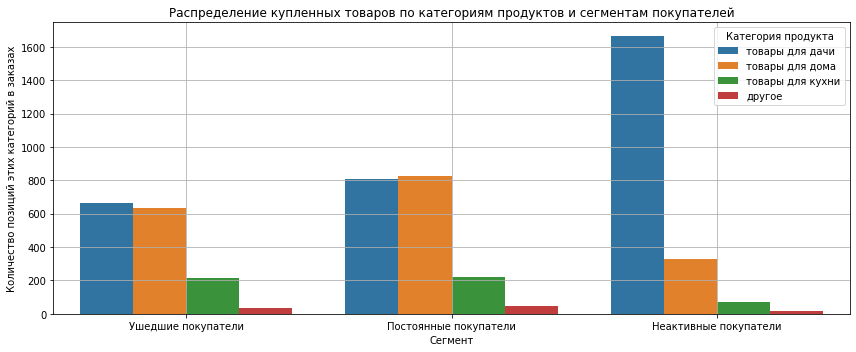

In [65]:
# повторяем построение столбчатой диаграммы
plt.figure(figsize=(12, 5))
sns.barplot(data=product_cat, x='group', y='cnt_products', hue='product_category')
plt.title('Распределение купленных товаров по категориям продуктов и сегментам покупателей')
plt.xlabel('Сегмент')
plt.ylabel('Количество позиций этих категорий в заказах')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Категория продукта')
plt.show()

##### Сезонность товаров по выделенным сегментам пользователей

In [66]:
data.head()

,date,customer_id,order_id,product,quantity,price,check,product_category,group,year_month
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.0,1037.0,товары для дачи,Ушедшие покупатели,2018-10


In [67]:
# создадим 3 таблицы, где будут данные о покупках по каждому сегменту пользователей
lost = data.query('group == "Ушедшие покупатели"')
inactive = data.query('group == "Неактивные покупатели"')
permanent = data.query('group == "Постоянные покупатели"')

In [68]:
# посчитаем частоту встречаемости товаров разных категорий в заказах в каждом месяце в сегменте "Ушедшие покупатели"
season_goods_lost = lost.groupby(['product_category', 'year_month'])['product'].count().reset_index()
display(season_goods_lost.head())

# в сегменте "Неактивные пользователи"
season_goods_inactive = inactive.groupby(['product_category', 'year_month'])['product'].count().reset_index()
season_goods_inactive = season_goods_inactive.sort_values(by='year_month')

# в сегменте "Постоянные пользователи"
season_goods_permanent = permanent.groupby(['product_category', 'year_month'])['product'].count().reset_index()
season_goods_permanent = season_goods_permanent.sort_values(by='year_month')

,product_category,year_month,product
0,другое,2018-10,13
1,другое,2018-11,9
2,другое,2018-12,7
3,другое,2019-01,4
4,другое,2019-02,2


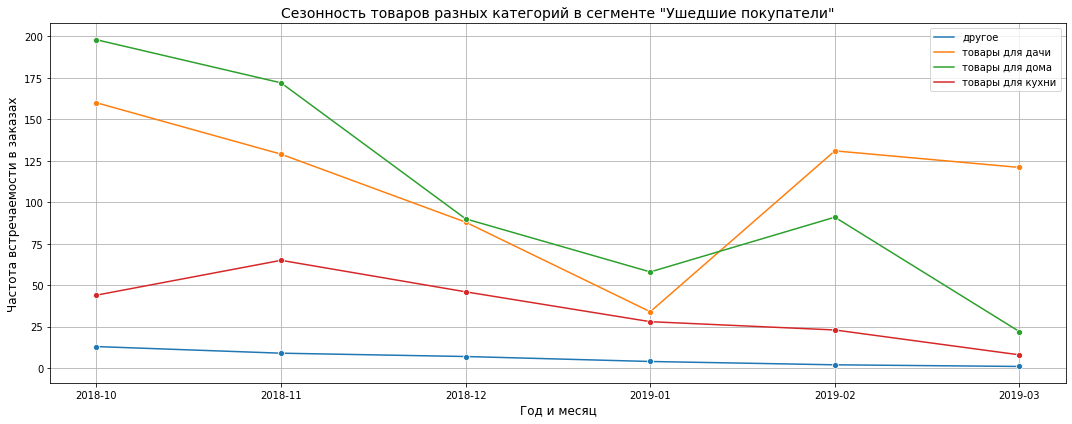

In [69]:
# строим линейный график частоты встречаемости товаров разных категорий у покупателей из сегмента "Ушедшие покупатели"
# (смотрим сезонность)
plt.figure(figsize=(15, 6))
sns.lineplot(data=season_goods_lost, x='year_month', y='product', marker='o', hue='product_category')

# оформляем график
plt.xlabel('Год и месяц', fontsize=12)
plt.ylabel('Частота встречаемости в заказах', fontsize=12)
plt.title('Сезонность товаров разных категорий в сегменте "Ушедшие покупатели"', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

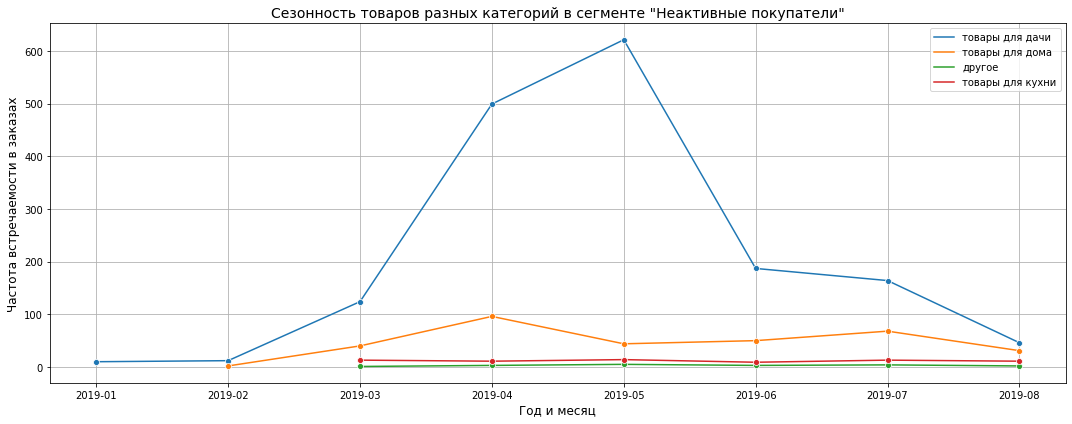

In [70]:
# строим линейный график частоты встречаемости товаров разных категорий у покупателей из сегмента "Неактивные покупатели"
# (смотрим сезонность)
plt.figure(figsize=(15, 6))
sns.lineplot(data=season_goods_inactive, x='year_month', y='product', marker='o', hue='product_category')

# оформляем график
plt.xlabel('Год и месяц', fontsize=12)
plt.ylabel('Частота встречаемости в заказах', fontsize=12)
plt.title('Сезонность товаров разных категорий в сегменте "Неактивные покупатели"', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

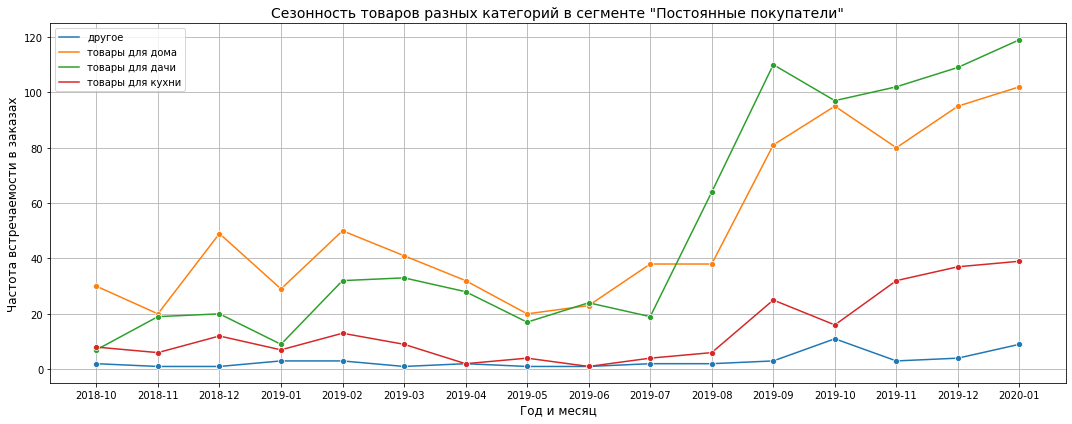

In [71]:
# строим линейный график частоты встречаемости товаров разных категорий у покупателей из сегмента "Постоянные покупатели"
# (смотрим сезонность)
plt.figure(figsize=(15, 6))
sns.lineplot(data=season_goods_permanent, x='year_month', y='product', marker='o', hue='product_category')

# оформляем график
plt.xlabel('Год и месяц', fontsize=12)
plt.ylabel('Частота встречаемости в заказах', fontsize=12)
plt.title('Сезонность товаров разных категорий в сегменте "Постоянные покупатели"', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Сезонность товаров у покупателей из сегмента "Ушедшие покупатели" в период с 10.2018 по 03.2019:
- осенью наибольшей популярностью пользовались товары для дома и активнее обычного покупали товары для кухни
- зимой было "затишье", однако в феврале увеличился спрос на товары для дачи и для дома
- в начале весны товары для дачи все так же были очень востребованы, а спрос на товары для дома и кухни упал
- на другие товары спрос был не очень выражен в течение почти всего периода, за исключением последних месяцев осени и первого месяца зимы 
<br>
<br>

Сезонность товаров у покупателей из сегмента "Неактивные покупатели" в период с 01.2019 по 08.2019:
- весной и летом заметнее всего был выражен спрос на товары для дачи - спрос рос с 02.2019 по 05.2019 и снизился после
- также в середине весна и середине лета было небольшое увеличение спроса на товары для дома, но в течение всего рассматриваемого периода товары для дома более востребованы, чем товары для кухни или другие
- зимой было "затишье"
<br>
<br>

Сезонность товаров у покупателей из сегмента "Постоянные покупатели" в период с 10.2018 по 01.2020:
- в течение всего срока наибольшей популярностью пользовались товары из категорий "для дома" и "для дачи"
- товары из категории "другое" имели выраженный спрос только зимой в 2019 и в 2020 г, а также в середине осени 2019 
- товары для кухни в некоторой степени были популярны, но активнее всего их покупали зимой 2018-2019 гг и с середины осени 2019 до начала зимы 2020 (конца исследуемого периода)
- зимой наибольшим спросом пользовались товары для дома и для дачи, причем зимой 2019 преобладали товары для дома, а зимой 2020 товары для дачи
- весной 2019 года наиболее популярными были товары для дома, хотя резко увеличилось количество купленных товаров для дачи
- в середине лета 2019 товары для дачи обогнали по популярности товары для дома и очень высокий спрос на них сохранялся вплоть до зимы 2020 
- осенью первенство также сохраняли категории "для дома" и "для дачи": осенью 2018 - для дома, а осенью 2019 - для дачи

##### Вывод

Наиболее популярными категориями по всем сегментам являются "Товары для дачи" и "Товары для дома".\
<br>

Сезонность товаров у покупателей из сегмента "Ушедшие покупатели" в период с 10.2018 по 03.2019:
- осенью наибольшей популярностью пользовались товары для дома и активнее обычного покупали товары для кухни
- зимой было "затишье", однако в феврале увеличился спрос на товары для дачи и для дома
- в начале весны товары для дачи все так же были очень востребованы, а спрос на товары для дома и кухни упал
- на другие товары спрос был не очень выражен в течение почти всего периода, за исключением последних месяцев осени и первого месяца зимы 
<br>
<br>

Сезонность товаров у покупателей из сегмента "Неактивные покупатели" в период с 01.2019 по 08.2019:
- весной и летом заметнее всего был выражен спрос на товары для дачи - спрос рос с 02.2019 по 05.2019 и снизился после
- таккже в середине весна и середине лета было небольшое увеличение спроса на товары для дома, но в течение всего рассматриваемого периода товары для дома более востребованы, чем товары для кухни или другие
- зимой было "затишье"
<br>
<br>

Сезонность товаров у покупателей из сегмента "Постоянные покупатели" в период с 10.2018 по 01.2020:
- в течение всего срока наибольшей популярностью пользовались товары из категорий "для дома" и "для дачи"
- товары из категории "другое" имели выраженный спрос только зимой в 2019 и в 2020 г, а также в середине осени 2019 
- товары для кухни в некоторой степени были популярны, но активнее всего их покупали зимой 2018-2019 гг и с середины осени 2019 до начала зимы 2020 (конца исследуемого периода)
- зимой наибольшим спросом пользовались товары для дома и для дачи, причем зимой 2019 преобладали товары для дома, а зимой 2020 товары для дачи
- весной 2019 года наиболее популярными были товары для дома, хотя резко увеличилось количество купленных товаров для дачи
- в середине лета 2019 товары для дачи обогнали по популярности товары для дома и очень высокий спрос на них сохранялся вплоть до зимы 2020 
- осенью первенство также сохраняли категории "для дома" и "для дачи": осенью 2018 - для дома, а осенью 2019 - для дачи

#### Вывод по исследовательскому анализу данных

1. **Временной период исследования**\
Минимальная дата: 2018-10-01\
Максимальная дата: 2020-01-31\
Доступный для исследования период: 487 дней
<br>
<br>

2. **Основные показатели интернет-магазина**\
Начиная с октября 2018 года, основные показатели интернет-магазина, такие как помесячная выручка, средний чек и помесячная средняя выручка с покупателя, демонстрируют снижение по месяцам. Минимумы за исследуемый период были достигнуты в ноябре 2019 года.\
Однако показатель среднего чека держался примерно на одном уровне в период с января по октябрь 2019г, а средней выручки с покупателя - с февраля по октябрь того же года. При этом наблюдался резкий пик по показателю средней выручки в мае 2019 года, а среднего чека в июне 2019 года (с 04.2019 и последующим снижением по 07.2019).\
Средний чек за весь период составил 607.5.\
Средняя выручка с покупателя за весь период составила 604.5.
<br>
<br>

3. **Категоризация товаров**\
Было выделено 4 категории товаров: товары для дома, для дачи, для кухни и другое.\
Самая популярная категория - товары для дачи (их наименования встречаются в заказах 3135 раз), реже всего встречаются наименования товаров категории "другое" (103).
<br>
<br>

4. **Сегментация пользователей**\
С помощью RFM-анализа покупатели были распределены на три сегмента на основе данных о их покупках:
- ушедшие покупатели, которые покупали единоразово и на небольшие суммы или давно не покупали
- неактивные покупатели, это относительно недавние клиенты, которые пришли единоразово, или те, которые покупали часто, но по какой-то причине перестали 
- постоянные покупатели, это покупатели, которые покупали недавно, или которые покупают постоянно за любую сумму
<br>
<br>

5. **Анализ сегментов пользователей**\
1) Всего уникальных покупателей в интернет-магазине 2420.\
Они были распределены на три сегмента на основе их покупок: давности, их количества и общей потраченной суммы.\
Больше всего покупателей в сегменте "Постоянные" - 1048 человек, это хороший показатель, так как это новые покупатели или те, которые достаточно часто и/или на хорошие суммы закупаются у нас.\
При этом ушедших покупателей достаточно много - 705 человек, стоит рассмотреть методы для их возврата.\
Неактивных покупателей около 667, это те люди, которые недавно совершали покупки, но по какой-то причине перестали, также стоит рассмотреть возможные причины и способы их возврата.
<br>

2) Средний чек по сегментам в общем:
- неактивные покупатели - 632.0
- постоянные покупатели - 442.0
- ушедшие покупатели - 749.0

Средний чек по сегментам в динамике: 
- у постоянных клиентов на протяжении почти всего периода средний чек был на том же уровне, что и средние чеки у других сегментов, он держался на уровне примерно 450-750, однако с 10.2019 года он за месяц снизился до минимума - около 200.
- у неактивных покупателей в 01.2019 года был самый высокий показатель среднего чека (1400), но он за месяц снизился до 500, далее он держался примерно на том же уровне, как у других сегментов. Однако в 05.2019 он вырос и снова пришел к предпиковому значению.  Период, за который известны данные о неактивных покупателях, составляет 8 месяцев (01.2019 - 08.2019).
- средний чек у ушедших покупателей снизился к 01.2019 с 950 до 600, но потом незначительно увеличился (диапазон за весь период примерно равен 600-950). Период составляет 6 месяцев (10.2018-03.2019).
- интересно то, что, когда у неактивных покупателей 05.2019 средний чек вырос, у постоянных покупателей этот показатель наоборот снизился
<br>

3) У ушедших и неактивных покупателей наиболее популярной является категория товаров для дачи, причем у неактивных покупателей она встречается в 3-4 раза чаще в данных, чем у них же категория товаров для дома, в то время как у ушедших примерно одинаково популярны товары для дома и для дачи. Скорее всего это объясняется тем, что период активности неактивных покупателей выпал на весну-лето 2019 года.\
У постоянных покупателей более популярны товары для дома, но при это разница между ними и товарами для дачи несущественна.\
Реже всего у всех сегментов пользователей встречаются заказы с товарами из категории Другое.
<br>

В топ-5 наиболее часто встречаемых в заказах наименований товаров:
- у ушедших пользователей входят: 3 сорта пеларгонии, 1 сорт герани домашней и сумка-тележка
- у неактивных: 5 сортов пеларгонии
- у постоянных: 3 сорта пеларгонии, тележка багажная и сумка-тележка

Сорта пеларгонии пользуются большой популярностью у всех покупателей. Количество заказов с ними в разных сегментах колеблется от 11 до 35.\
Тележки двух видов (сумка-тележка и тележка багажная) встречаются реже (в 12-21 заказе).
<br>

4) Больше всего заказов было сделано покупателями из сегмента "Постоянные" (1824), у ушедших покупателей 918 заказов, а у неактивных - 761.\
В среднем на любого покупателя приходится от 1.14-1.74 заказа: наивысший показатель у постоянных посетителей (1.74), а наименьший у неактивных (1.14), у ушедших примерно 1.3 заказа в среднем.
<br>

5) Больше всего выручки принесли магазину постоянные покупатели (1.64 млн), меньше всего - неактивные покупатели (0.82 млн); ушедшие покупатели сделали заказов на 1.1 млн.
<br>
<br>

6. **Анализ категорий товаров**\
1) Наиболее популярными категориями по всем сегментам являются "Товары для дачи" и "Товары для дома".
<br>

2) Сезонность товаров у покупателей из сегмента "Ушедшие покупатели" в период с 10.2018 по 03.2019:
- осенью наибольшей популярностью пользовались товары для дома и активнее обычного покупали товары для кухни
- зимой было "затишье", однако в феврале увеличился спрос на товары для дачи и для дома
- в начале весны товары для дачи все так же были очень востребованы, а спрос на товары для дома и кухни упал
- на другие товары спрос был не очень выражен в течение почти всего периода, за исключением последних месяцев осени и первого месяца зимы 
<br>

Сезонность товаров у покупателей из сегмента "Неактивные покупатели" в период с 01.2019 по 08.2019:
- весной и летом заметнее всего был выражен спрос на товары для дачи - спрос рос с 02.2019 по 05.2019 и снизился после
- таккже в середине весна и середине лета было небольшое увеличение спроса на товары для дома, но в течение всего рассматриваемого периода товары для дома более востребованы, чем товары для кухни или другие
- зимой было "затишье"
<br>

Сезонность товаров у покупателей из сегмента "Постоянные покупатели" в период с 10.2018 по 01.2020:
- в течение всего срока наибольшей популярностью пользовались товары из категорий "для дома" и "для дачи"
- товары из категории "другое" имели выраженный спрос только зимой в 2019 и в 2020 г, а также в середине осени 2019 
- товары для кухни в некоторой степени были популярны, но активнее всего их покупали зимой 2018-2019 гг и с середины осени 2019 до начала зимы 2020 (конца исследуемого периода)
- зимой наибольшим спросом пользовались товары для дома и для дачи, причем зимой 2019 преобладали товары для дома, а зимой 2020 товары для дачи
- весной 2019 года наиболее популярными были товары для дома, хотя резко увеличилось количество купленных товаров для дачи
- в середине лета 2019 товары для дачи обогнали по популярности товары для дома и очень высокий спрос на них сохранялся вплоть до зимы 2020 
- осенью первенство также сохраняли категории "для дома" и "для дачи": осенью 2018 - для дома, а осенью 2019 - для дачи

### Основные вопросы исследования

#### Каким клиентам и в какие периоды необходимо рассылать рекламные предложения по определённым категориям товаров?

Клиентам из сегмента "Ушедшие покупатели" стоит рассылать рекламные предложения:
- о скидках, программы лояльности 
- осенью и в конце зимы-весной
- товары из категорий "Товары для дома" и "Товары для дачи"
<br>
<br>

Клиентам из сегмента "Неактивные покупатели" стоит рассылать рекламные предложения:
- о специальных предложениях, акциях 
- весной
- товары из категории "Товары для дачи"
<br>
<br>

Клиентам из сегмента "Постоянные покупатели" стоит рассылать рекламные предложения:
- рассылки с сопутствующими товарами (для тех, у кого средний чек небольшой) или предложение программы лояльности/приглашение в VIP-клуб
- круглогодично
- товары из категории "Товары для дачи" и "Товары для дома"
- опционально можно осенью-зимой о товарах из категории "Товары для кухни"

#### Какую стратегию по увеличению количества продаваемого товара для каждого сегмента покупателей можно предложить?

*Для ушедших покупателей:*\
Самое важное - вернуть их.\
Можно попробовать их вернуть с помощью рассылки о программе лояльности (например, кэшбек за покупки), о скидке на первые несколько товаров, приобретенных после возвращения, или о розыгрыше крупного приза (автомобиль/квартира).

*Для неактивных покупателей:*\
Важно их вернуть и заинтересовать товарами.\
Можно попробовать задействовать персональный подход - обзвонить покупателей, которые в прошлом активно пользовались сервисом, или которые сделали покупки на достаточно крупные суммы. Им можно предложить программу лояльности (постоянную скидку или кэшбек), акцию на сезонные товары, скидки на сопутствующие товары или бонусы от партнеров нашего магазина.


*Для постоянных покупателей:*\
Можно персонально наиболее прибыльным покупателям предложить воспользоваться возможностями и бонусами VIP-клуба.\
Покупателям, которые пользуются нашим сервисом часто, но на небольшие суммы, можно предложить акции и скидки на сопутствующие товары.\
Клиентам, которые только недавно начали пользоваться сервисом, можно предложить ту же программу лояльности.

#### Какие способы повышения возвращаемости покупателей из различных сегментов можно предложить?

Предполагаю, эффективнее всего для всех сегментов сработает программа лояльности и, возможно, бонусы от партнеров.

### Проверка статистических гипотез

Проверка гипотез будет проводиться с помощью теста Манна-Уитни и поправки Бонферрони на многократную проверку гипотез, так как несколько независимых выборок, которые нужно сравнить между собой.

#### Гипотеза 1 - Различается ли средний чек у покупателей из разных сегментов?

H0 - средний чек у покупателей из разных сегментов не отличается\
H1 - средний чек отличается

Создадим функцию для попарного множественного сравнения показателей по сегментам

In [72]:
def test_values(df):
    
    # названия групп для анализа
    groups = ["Ушедшие покупатели", "Неактивные покупатели", "Постоянные покупатели"]
    
    # создаем списки для хранения результатов
    results = []

    # рассчитываем p-value и дельты для всех пар групп
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            group1 = groups[i]
            group2 = groups[j]
            
            # расчет p-value
            pvalue = st.mannwhitneyu(
                df.query(f'group == "{group1}"')['check'],
                df.query(f'group == "{group2}"')['check']
            )[1]

            # расчет относительного прироста среднего чека
            delta = (df.query(f'group == "{group1}"')['check'].mean() /
                     df.query(f'group == "{group2}"')['check'].mean()) - 1
            
            # добавление результатов в список
            results.append({
                'groups_tested': f'{group1.capitalize()} и {group2.capitalize()}',
                'p-value': round(pvalue, 5),
                'delta': round(delta, 5)
            })

    # создаем DataFrame из результатов
    test_values_df = pd.DataFrame(results)
    test_values_df = test_values_df.set_index('groups_tested')

    # примененяем поправки Бонферрони
    num_tests = len(results)  # Количество проведенных тестов
    test_values_df['p-value_bonferroni'] = round(test_values_df['p-value'] * num_tests, 5)

    # определяем значимости с учетом поправки
    alpha = 0.05  
    test_values_df['significant'] = test_values_df['p-value_bonferroni'] < alpha

    return test_values_df

In [73]:
# проводим тест для сравнения среднего чека у покупателей из разных сегментов
results = test_values(unique_orders_data)

# смотрим результаты
display(results)

,p-value,delta,p-value_bonferroni,significant
groups_tested,,,,
Ушедшие покупатели и Неактивные покупатели,0.00916,0.10745,0.02748,True
Ушедшие покупатели и Постоянные покупатели,0.00000,0.33345,0.00000,True
Неактивные покупатели и Постоянные покупатели,0.00000,0.20408,0.00000,True


Отвергаем нулевую гипотезу, так как p-value и p-value_bonferroni меньше 0.05 для всех пар сегментов, то есть средний чек у покупателей из разных сегментов статистически отличается.

#### Гипотеза 2 - Различается ли среднее количество заказов в разных сегментах?

H0 - среднее количество заказов в разных сегментах не отличается\
H1 - среднее количество заказов в разных сегментах отличается

In [74]:
# отредактируем названия столбцов таблицы с количеством заказов у уникальных покупателей каждого сегмента
# (она была создана в пункте 3.5.4)
unique_orders_count.columns = ['customer_id', 'group', 'orders_count']
display(unique_orders_count)

,customer_id,group,orders_count
0,000d6849-084e-4d9f-ac03-37174eaf60c4,Постоянные покупатели,1
1,001cee7f-0b29-4716-b202-0042213ab038,Ушедшие покупатели,1
2,00299f34-5385-4d13-9aea-c80b81658e1b,Постоянные покупатели,1
3,002d4d3a-4a59-406b-86ec-c3314357e498,Ушедшие покупатели,1
4,003bbd39-0000-41ff-b7f9-2ddaec152037,Постоянные покупатели,1
...,...,...,...
2415,ff601403-b094-4b86-9ac6-264d725b9277,Постоянные покупатели,2
2416,ffaeab76-3a8d-49ee-860f-17273b2fc8a2,Постоянные покупатели,1
2417,ffb5976a-7a4d-460b-95c4-5ffaba31cb24,Ушедшие покупатели,1
2418,ffb80538-3fda-4351-8ea9-9d2bec58bb07,Постоянные покупатели,1


In [75]:
def test_values2(df):
    # названия групп для анализа
    groups = ["Ушедшие покупатели", "Неактивные покупатели", "Постоянные покупатели"]

    # создаем списки для хранения результатов
    results = []

    # количество пар сравнения
    num_tests = len(groups) * (len(groups) - 1) / 2

    # рассчитываем p-value и дельты для всех пар групп
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            group1 = groups[i]
            group2 = groups[j]

            # выбор данных для каждой группы
            data1 = df.query(f'group == "{group1}"')['orders_count']
            data2 = df.query(f'group == "{group2}"')['orders_count']

            # расчет p-value
            pvalue = st.mannwhitneyu(data1, data2)[1]

            # расчет относительного прироста среднего
            mean1 = data1.mean()
            mean2 = data2.mean()
            delta = (mean1 / mean2) - 1 if mean2 != 0 else float('inf')  # Избегаем деления на ноль

            # добавление результатов в список
            results.append({
                'groups_tested': f'{group1.capitalize()} и {group2.capitalize()}',
                'p-value': round(pvalue, 5),
                'delta': round(delta, 5)
            })

    # создаем DataFrame из результатов
    test_values_df = pd.DataFrame(results)
    test_values_df = test_values_df.set_index('groups_tested')

    # применяем поправки Бонферрони
    test_values_df['p-value_bonferroni'] = round(test_values_df['p-value'] * num_tests, 5)

    # определяем значимости с учетом поправки
    alpha = 0.05
    test_values_df['significant'] = test_values_df['p-value_bonferroni'] < alpha

    return test_values_df

In [76]:
# проводим тест для сравнения среднего количества заказов у покупателей из разных сегментов
results2 = test_values2(unique_orders_count)

# смотрим результаты
display(results2)

,p-value,delta,p-value_bonferroni,significant
groups_tested,,,,
Ушедшие покупатели и Неактивные покупатели,0.01276,0.14103,0.03828,True
Ушедшие покупатели и Постоянные покупатели,0.00000,-0.25103,0.00000,True
Неактивные покупатели и Постоянные покупатели,0.00000,-0.34360,0.00000,True


Отвергаем нулевую гипотезу, так как p-value и p-value_bonferroni меньше 0.05 для всех пар сегментов: среднее количество заказов у покупателей из разных сегментов статистически отличается.

#### Вывод после статистической проверки гипотез

Так как проверка обеих гипотез показала статистически значимую разницу между показателями среднего чека и среднего количества заказов на покупателя по разным сегментам, можно утверждать, что сегментация пользователей была проведена корректно.

### Итоговый вывод, возможные рекомендации

**Исследование проводилось на основе:**\
Данных о транзакциях интернет-магазина товаров для дома и быта «Пока все ещё тут»
<br>
<br>

**Задача была следующая:**\
Исходя из анализа сегментов покупателей, разработать рекомендации для таргетированной рекламы с целью увеличения продаж, возврата ушедших покупателей, повышения лояльности клиентов, конверсии и других ключевых показателей эффективности бизнеса.
<br>
<br>

**На этапе предобработки:**
- был изменен тип данных столбца date на datetime;
- пропусков и явных дубликатов обнаружено не было;
- были обнаружены и удалены неявные дубликаты, которые скорее всего возникли в результате сбоя (26.02% данных);
- добавлен столбец check с итоговой стоимостью заказа (чеком);
- были обнаружены и удалены выбросы по 99.5-му перцентелю столбца чека за покупки(0.86% данных).
<br>
<br>

**Исследовательский анализ данных:**
1. *Временной период исследования*\
Минимальная дата: 2018-10-01\
Максимальная дата: 2020-01-31\
Доступный для исследования период: 487 дней
<br>
<br>

2. *Основные показатели интернет-магазина*\
Начиная с октября 2018 года, основные показатели интернет-магазина, такие как помесячная выручка, средний чек и помесячная средняя выручка с покупателя, демонстрируют снижение по месяцам. Минимумы за исследуемый период были достигнуты в ноябре 2019 года.\
Однако показатель среднего чека держался примерно на одном уровне в период с января по октябрь 2019г, а средней выручки с покупателя - с февраля по октябрь того же года. При этом наблюдался резкий пик по показателю средней выручки в мае 2019 года, а среднего чека в июне 2019 года (с 04.2019 и последующим снижением по 07.2019).\
Средний чек за весь период составил 607.5.\
Средняя выручка с покупателя за весь период составила 604.5.
<br>
<br>

3. *Категоризация товаров*\
Было выделено 4 категории товаров: товары для дома, для дачи, для кухни и другое.\
Самая популярная категория - товары для дачи (их наименования встречаются в заказах 3135 раз), реже всего встречаются наименования товаров категории "другое" (103).
<br>
<br>

4. *Сегментация пользователей*\
С помощью RFM-анализа покупатели были распределены на три сегмента на основе данных о их покупках:
- ушедшие покупатели, которые покупали единоразово и на небольшие суммы или давно не покупали
- неактивные покупатели, это относительно недавние клиенты, которые пришли единоразово, или те, которые покупали часто, но по какой-то причине перестали 
- постоянные покупатели, это покупатели, которые покупали недавно, или которые покупают постоянно за любую сумму
<br>
<br>

5. *Анализ сегментов пользователей*\
1) Всего уникальных покупателей в интернет-магазине 2420.\
Они были распределены на три сегмента на основе их покупок: давности, их количества и общей потраченной суммы.\
Больше всего покупателей в сегменте "Постоянные" - 1048 человек, это хороший показатель, так как это новые покупатели или те, которые достаточно часто и/или на хорошие суммы закупаются у нас.\
При этом ушедших покупателей достаточно много - 705 человек, стоит рассмотреть методы для их возврата.\
Неактивных покупателей около 667, это те люди, которые недавно совершали покупки, но по какой-то причине перестали, также стоит рассмотреть возможные причины и способы их возврата.
<br>

2) Средний чек по сегментам в общем:
- неактивные покупатели - 632.0
- постоянные покупатели - 442.0
- ушедшие покупатели - 749.0

Средний чек по сегментам в динамике: 
- у постоянных клиентов на протяжении почти всего периода средний чек был на том же уровне, что и средние чеки у других сегментов, он держался на уровне примерно 450-750, однако с 10.2019 года он за месяц снизился до минимума - около 200.
- у неактивных покупателей в 01.2019 года был самый высокий показатель среднего чека (1400), но он за месяц снизился до 500, далее он держался примерно на том же уровне, как у других сегментов. Однако в 05.2019 он вырос и снова пришел к предпиковому значению.  Период, за который известны данные о неактивных покупателях, составляет 8 месяцев (01.2019 - 08.2019).
- средний чек у ушедших покупателей снизился к 01.2019 с 950 до 600, но потом незначительно увеличился (диапазон за весь период примерно равен 600-950). Период составляет 6 месяцев (10.2018-03.2019).
- интересно то, что, когда у неактивных покупателей 05.2019 средний чек вырос, у постоянных покупателей этот показатель наоборот снизился
<br>

3) У ушедших и неактивных покупателей наиболее популярной является категория товаров для дачи, причем у неактивных покупателей она встречается в 3-4 раза чаще в данных, чем у них же категория товаров для дома, в то время как у ушедших примерно одинаково популярны товары для дома и для дачи. Скорее всего это объясняется тем, что период активности неактивных покупателей выпал на весну-лето 2019 года.\
У постоянных покупателей более популярны товары для дома, но при это разница между ними и товарами для дачи несущественна.\
Реже всего у всех сегментов пользователей встречаются заказы с товарами из категории Другое.
<br>

В топ-5 наиболее часто встречаемых в заказах наименований товаров:
- у ушедших пользователей входят: 3 сорта пеларгонии, 1 сорт герани домашней и сумка-тележка
- у неактивных: 5 сортов пеларгонии
- у постоянных: 3 сорта пеларгонии, тележка багажная и сумка-тележка

Сорта пеларгонии пользуются большой популярностью у всех покупателей. Количество заказов с ними в разных сегментах колеблется от 11 до 35.\
Тележки двух видов (сумка-тележка и тележка багажная) встречаются реже (в 12-21 заказе).
<br>

4) Больше всего заказов было сделано покупателями из сегмента "Постоянные" (1824), у ушедших покупателей 918 заказов, а у неактивных - 761.\
В среднем на любого покупателя приходится от 1.14-1.74 заказа: наивысший показатель у постоянных посетителей (1.74), а наименьший у неактивных (1.14), у ушедших примерно 1.3 заказа в среднем.
<br>

5) Больше всего выручки принесли магазину постоянные покупатели (1.64 млн), меньше всего - неактивные покупатели (0.82 млн); ушедшие покупатели сделали заказов на 1.1 млн.
<br>
<br>

6. *Анализ категорий товаров*\
1) Наиболее популярными категориями по всем сегментам являются "Товары для дачи" и "Товары для дома".
<br>

2) Сезонность товаров у покупателей из сегмента "Ушедшие покупатели" в период с 10.2018 по 03.2019:
- осенью наибольшей популярностью пользовались товары для дома и активнее обычного покупали товары для кухни
- зимой было "затишье", однако в феврале увеличился спрос на товары для дачи и для дома
- в начале весны товары для дачи все так же были очень востребованы, а спрос на товары для дома и кухни упал
- на другие товары спрос был не очень выражен в течение почти всего периода, за исключением последних месяцев осени и первого месяца зимы 
<br>

Сезонность товаров у покупателей из сегмента "Неактивные покупатели" в период с 01.2019 по 08.2019:
- весной и летом заметнее всего был выражен спрос на товары для дачи - спрос рос с 02.2019 по 05.2019 и снизился после
- таккже в середине весна и середине лета было небольшое увеличение спроса на товары для дома, но в течение всего рассматриваемого периода товары для дома более востребованы, чем товары для кухни или другие
- зимой было "затишье"
<br>

Сезонность товаров у покупателей из сегмента "Постоянные покупатели" в период с 10.2018 по 01.2020:
- в течение всего срока наибольшей популярностью пользовались товары из категорий "для дома" и "для дачи"
- товары из категории "другое" имели выраженный спрос только зимой в 2019 и в 2020 г, а также в середине осени 2019 
- товары для кухни в некоторой степени были популярны, но активнее всего их покупали зимой 2018-2019 гг и с середины осени 2019 до начала зимы 2020 (конца исследуемого периода)
- зимой наибольшим спросом пользовались товары для дома и для дачи, причем зимой 2019 преобладали товары для дома, а зимой 2020 товары для дачи
- весной 2019 года наиболее популярными были товары для дома, хотя резко увеличилось количество купленных товаров для дачи
- в середине лета 2019 товары для дачи обогнали по популярности товары для дома и очень высокий спрос на них сохранялся вплоть до зимы 2020 
- осенью первенство также сохраняли категории "для дома" и "для дачи": осенью 2018 - для дома, а осенью 2019 - для дачи
<br>
<br>

**Ответы на основные вопросы исследования:**
1. *Каким клиентам и в какие периоды необходимо рассылать рекламные предложения по определённым категориям товаров?*\
Клиентам из сегмента "Ушедшие покупатели" стоит рассылать рекламные предложения:
- о скидках, программы лояльности 
- осенью и в конце зимы-весной
- товары из категорий "Товары для дома" и "Товары для дачи"
<br>
<br>

Клиентам из сегмента "Неактивные покупатели" стоит рассылать рекламные предложения:
- о специальных предложениях, акциях 
- весной
- товары из категории "Товары для дачи"
<br>
<br>

Клиентам из сегмента "Постоянные покупатели" стоит рассылать рекламные предложения:
- рассылки с сопутствующими товарами (для тех, у кого средний чек небольшой) или предложение программы лояльности/приглашение в VIP-клуб
- круглогодично
- товары из категории "Товары для дачи" и "Товары для дома"
- опционально можно осенью-зимой о товарах из категории "Товары для кухни"
<br>
<br>

2. *Какую стратегию по увеличению количества продаваемого товара для каждого сегмента покупателей можно предложить?*
*Для ушедших покупателей:*\
Самое важное - вернуть их.\
Можно попробовать их вернуть с помощью рассылки о программе лояльности (например, кэшбек за покупки), о скидке на первые несколько товаров, приобретенных после возвращения, или о розыгрыше крупного приза (автомобиль/квартира).

*Для неактивных покупателей:*\
Важно их вернуть и заинтересовать товарами.\
Можно попробовать задействовать персональный подход - обзвонить покупателей, которые в прошлом активно пользовались сервисом, или которые сделали покупки на достаточно крупные суммы. Им можно предложить программу лояльности (постоянную скидку или кэшбек), акцию на сезонные товары, скидки на сопутствующие товары или бонусы от партнеров нашего магазина.

*Для постоянных покупателей:*\
Можно персонально наиболее прибыльным покупателям предложить воспользоваться возможностями и бонусами VIP-клуба.\
Покупателям, которые пользуются нашим сервисом часто, но на небольшие суммы, можно предложить акции и скидки на сопутствующие товары.\
Клиентам, которые только недавно начали пользоваться сервисом, можно предложить ту же программу лояльности.

3. *Какие способы повышения возвращаемости покупателей из различных сегментов можно предложить?*\
Предполагаю, эффективнее всего для всех сегментов сработает программа лояльности и, возможно, бонусы от партнеров.

**Проверка статистических гипотез:**\
Проверка обеих гипотез показала статистически значимую разницу между показателями среднего чека и среднего количества заказов на покупателя по разным сегментам, следовательно, сегментация пользователей была проведена корректно.


**Возможные рекомендации:**\
Для удержания покупателей, а также увеличения количества продаваемого товара могу рекомендовать рекламную рассылку покупателям из сегментов "Неактивные" и "Постоянные" товаров из категорий "Товары для дома" осенью и "Товаров для дачи" с конца зимы по конец лета.\
А для возврата "Ушедших" покупателей можно осуществить информирование об акциях и скидках и программе лояльности товаров для дома и для дачи с зимы по осень.